<a href="https://colab.research.google.com/github/Adhul-R/AI-Hackathon/blob/main/sem7_review2_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install -U xgboost imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore, ttest_rel, wilcoxon

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    label_binarize
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,
    precision_recall_fscore_support
)

from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier


RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_REPEATS = 4
VALIDATION_RUNS = N_SPLITS * N_REPEATS
CORRELATION_THRESHOLD = 0.90
PCA_VARIANCE = 0.95
ALPHA = 0.05

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

print("MULTICLASS FLOOD SEVERITY PREDICTION")
print("=" * 70)
print("Five primary algorithms will be evaluated.")
print("Additional algorithms will be tested automatically only if")
print("the primary models produce highly similar prediction patterns.")
print("=" * 70)


MULTICLASS FLOOD SEVERITY PREDICTION
Five primary algorithms will be evaluated.
Additional algorithms will be tested automatically only if
the primary models produce highly similar prediction patterns.


DATA COLLECTION


In [2]:
print("\n1. DATA COLLECTION")

uploaded = files.upload()

csv_files = [
    filename for filename in uploaded.keys()
    if filename.lower().endswith(".csv")
]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was uploaded.")

DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print("\nUploaded Dataset:", DATA_PATH)
print("Dataset Shape:", df.shape)

print("\nFirst Five Records:")
display(df.head())



1. DATA COLLECTION


Saving flood_dataset.csv to flood_dataset.csv

Uploaded Dataset: flood_dataset.csv
Dataset Shape: (20000, 22)

First Five Records:


,rainfall_intensity_mmhr,current_water_level_m,water_level_rise_rate_mhr,flow_rate_m3s,soil_moisture_pct,drain_blockage_pct,temperature_c,humidity_pct,atmospheric_pressure_hpa,ground_water_level_m,...,forecast_rainfall_3h_mm,forecast_rainfall_4h_mm,forecast_rainfall_5h_mm,elevation_m,slope_pct,impervious_surface_pct,drainage_capacity_m3s,land_use_code,land_use_name,flood_severity_stage
0,22.38,1.502,0.1934,86.022,42.85,14.56,26.53,61.57,1010.37,2.586,...,14.95,19.44,22.06,986.98,34.14,71.87,84.404,0,Sandy,1
1,31.33,1.782,0.2732,91.910,46.03,39.98,30.25,64.33,1007.96,2.608,...,17.76,20.36,25.70,1302.31,20.47,75.02,82.779,0,Sandy,1
2,38.35,2.313,0.3923,146.548,57.04,69.45,25.55,71.47,1004.03,3.699,...,24.19,31.51,36.31,1017.62,5.78,36.29,107.214,1,Loamy,2
3,31.56,1.963,0.3103,100.389,46.89,48.18,32.17,65.92,1008.81,2.918,...,18.39,20.51,27.93,549.78,8.78,27.18,41.864,1,Loamy,1
4,39.35,2.503,0.4301,150.857,61.65,13.15,33.52,71.97,1006.71,4.399,...,27.15,31.89,37.07,682.41,25.94,30.40,57.606,4,Rocky,2


TARGET COLUMN

In [3]:
TARGET_COLUMN = "flood_severity_stage"

if TARGET_COLUMN not in df.columns:

    possible_targets = [
        c for c in df.columns
        if any(
            keyword in c.lower()
            for keyword in [
                "target",
                "class",
                "label",
                "severity",
                "flood"
            ]
        )
    ]

    if len(possible_targets) == 0:
        raise ValueError(
            "Target column was not found automatically. "
            "Change TARGET_COLUMN near the beginning of the code."
        )

    TARGET_COLUMN = possible_targets[-1]

print("\nTarget Column:", TARGET_COLUMN)



Target Column: flood_severity_stage


 DATA INSPECTION

In [4]:
print("\n2. DATA INSPECTION")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nMissing Values:")
missing_table = df.isnull().sum().to_frame("Missing_Count")
missing_table["Missing_Percentage"] = (
    missing_table["Missing_Count"] / len(df) * 100
)
display(missing_table)

duplicate_count = df.duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)

print("\nDescriptive Statistics:")
display(df.describe(include="all").T)

print("\nNumerical Columns:")
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_columns)

print("\nCategorical Columns:")
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()
print(categorical_columns)



2. DATA INSPECTION

Column Names:
['rainfall_intensity_mmhr', 'current_water_level_m', 'water_level_rise_rate_mhr', 'flow_rate_m3s', 'soil_moisture_pct', 'drain_blockage_pct', 'temperature_c', 'humidity_pct', 'atmospheric_pressure_hpa', 'ground_water_level_m', 'forecast_rainfall_1h_mm', 'forecast_rainfall_2h_mm', 'forecast_rainfall_3h_mm', 'forecast_rainfall_4h_mm', 'forecast_rainfall_5h_mm', 'elevation_m', 'slope_pct', 'impervious_surface_pct', 'drainage_capacity_m3s', 'land_use_code', 'land_use_name', 'flood_severity_stage']

Data Types:


,Data_Type
rainfall_intensity_mmhr,float64
current_water_level_m,float64
water_level_rise_rate_mhr,float64
flow_rate_m3s,float64
soil_moisture_pct,float64
drain_blockage_pct,float64
temperature_c,float64
humidity_pct,float64
atmospheric_pressure_hpa,float64
ground_water_level_m,float64



Missing Values:


,Missing_Count,Missing_Percentage
rainfall_intensity_mmhr,0,0.0
current_water_level_m,0,0.0
water_level_rise_rate_mhr,0,0.0
flow_rate_m3s,0,0.0
soil_moisture_pct,0,0.0
drain_blockage_pct,0,0.0
temperature_c,0,0.0
humidity_pct,0,0.0
atmospheric_pressure_hpa,0,0.0
ground_water_level_m,0,0.0



Duplicate Rows: 0

Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rainfall_intensity_mmhr,20000.0,NaN,NaN,NaN,27.895695,16.260975,-5.23,15.02,25.9,39.1025,79.58
current_water_level_m,20000.0,NaN,NaN,NaN,1.745041,1.012365,-0.233,0.94,1.6225,2.447,5.026
water_level_rise_rate_mhr,20000.0,NaN,NaN,NaN,0.279273,0.164045,-0.0719,0.1502,0.2595,0.3927,0.812
flow_rate_m3s,20000.0,NaN,NaN,NaN,104.684058,61.055574,-19.357,56.00625,97.572,147.0105,300.373
soil_moisture_pct,20000.0,NaN,NaN,NaN,46.215111,15.255943,15.87,34.1075,44.37,56.7725,97.19
drain_blockage_pct,20000.0,NaN,NaN,NaN,39.945779,22.992735,0.0,19.97,39.91,59.73,80.0
temperature_c,20000.0,NaN,NaN,NaN,28.01038,3.977028,11.64,25.34,28.03,30.7,44.36
humidity_pct,20000.0,NaN,NaN,NaN,65.713744,9.293763,45.73,58.43,64.63,72.17,98.2
atmospheric_pressure_hpa,20000.0,NaN,NaN,NaN,1008.016356,4.29815,992.92,1005.08,1008.46,1011.27,1019.69
ground_water_level_m,20000.0,NaN,NaN,NaN,2.793608,1.620705,-0.285,1.50075,2.595,3.92125,7.84



Numerical Columns:
['rainfall_intensity_mmhr', 'current_water_level_m', 'water_level_rise_rate_mhr', 'flow_rate_m3s', 'soil_moisture_pct', 'drain_blockage_pct', 'temperature_c', 'humidity_pct', 'atmospheric_pressure_hpa', 'ground_water_level_m', 'forecast_rainfall_1h_mm', 'forecast_rainfall_2h_mm', 'forecast_rainfall_3h_mm', 'forecast_rainfall_4h_mm', 'forecast_rainfall_5h_mm', 'elevation_m', 'slope_pct', 'impervious_surface_pct', 'drainage_capacity_m3s', 'land_use_code', 'flood_severity_stage']

Categorical Columns:
['land_use_name']


TARGET VALIDATION

In [5]:
print("\nTarget Distribution Before Preprocessing:")

target_distribution_before = (
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .sort_index()
)

display(
    target_distribution_before.to_frame("Count")
)

df[TARGET_COLUMN] = pd.to_numeric(
    df[TARGET_COLUMN],
    errors="coerce"
)

df = df.dropna(subset=[TARGET_COLUMN]).copy()

df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

classes = np.sort(df[TARGET_COLUMN].unique())

print("\nDetected Target Classes:", classes)

if not set([0, 1, 2]).issubset(set(classes)):
    raise ValueError(
        f"Expected flood classes 0, 1 and 2, but detected {classes}."
    )

classes = np.array([0, 1, 2])


Target Distribution Before Preprocessing:


,Count
flood_severity_stage,
0,4724
1,7050
2,5439
3,2381
4,406



Detected Target Classes: [0 1 2 3 4]


SUPPORTING FIGURE - CLASS DISTRIBUTION


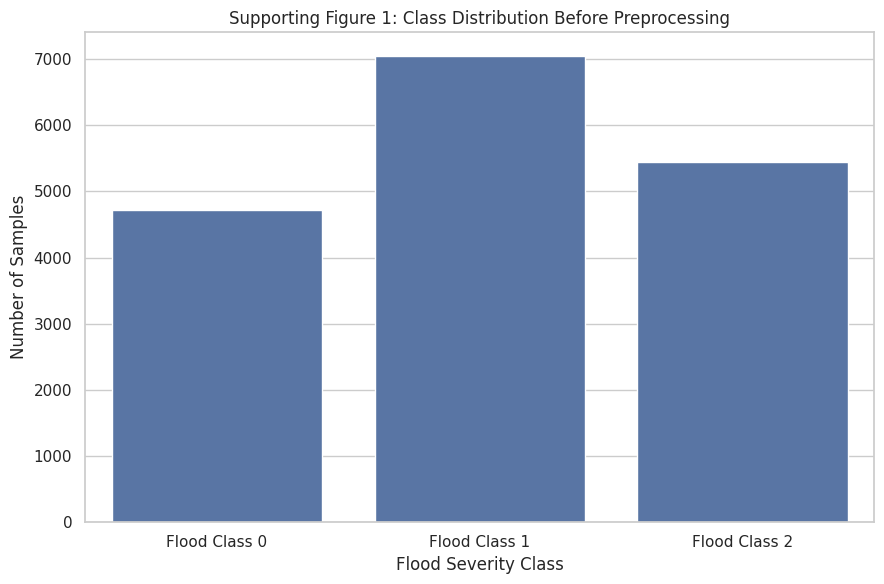

In [6]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    order=classes
)

plt.title("Supporting Figure 1: Class Distribution Before Preprocessing")
plt.xlabel("Flood Severity Class")
plt.ylabel("Number of Samples")
plt.xticks(
    range(len(classes)),
    [f"Flood Class {c}" for c in classes]
)
plt.tight_layout()
plt.show()

SUPPORTING FIGURE - MISSING VALUES

In [7]:
missing_plot = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_plot = missing_plot[missing_plot > 0]

if len(missing_plot) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values
    )

    plt.title("Supporting Figure 2: Missing Values by Feature")
    plt.xlabel("Feature")
    plt.ylabel("Missing Values")
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

else:

    print("\nNo missing values requiring visualization were detected.")


No missing values requiring visualization were detected.


 DUPLICATE REMOVAL

In [8]:
print("\n3. DATA CLEANING")

rows_before_duplicates = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after_duplicates = len(df)

print("Rows Before Duplicate Removal:", rows_before_duplicates)
print("Rows After Duplicate Removal:", rows_after_duplicates)
print("Duplicates Removed:", rows_before_duplicates - rows_after_duplicates)


# ============================================================
# PREPARE X AND y
# ============================================================

X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

original_feature_names = X.columns.tolist()

numeric_feature_names = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_feature_names = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nOriginal Number of Features:", X.shape[1])
print("Numerical Features:", len(numeric_feature_names))
print("Categorical Features:", len(categorical_feature_names))


3. DATA CLEANING
Rows Before Duplicate Removal: 20000
Rows After Duplicate Removal: 20000
Duplicates Removed: 0

Original Number of Features: 21
Numerical Features: 20
Categorical Features: 1


OUTLIER EDA BEFORE SPLIT


4. OUTLIER ANALYSIS


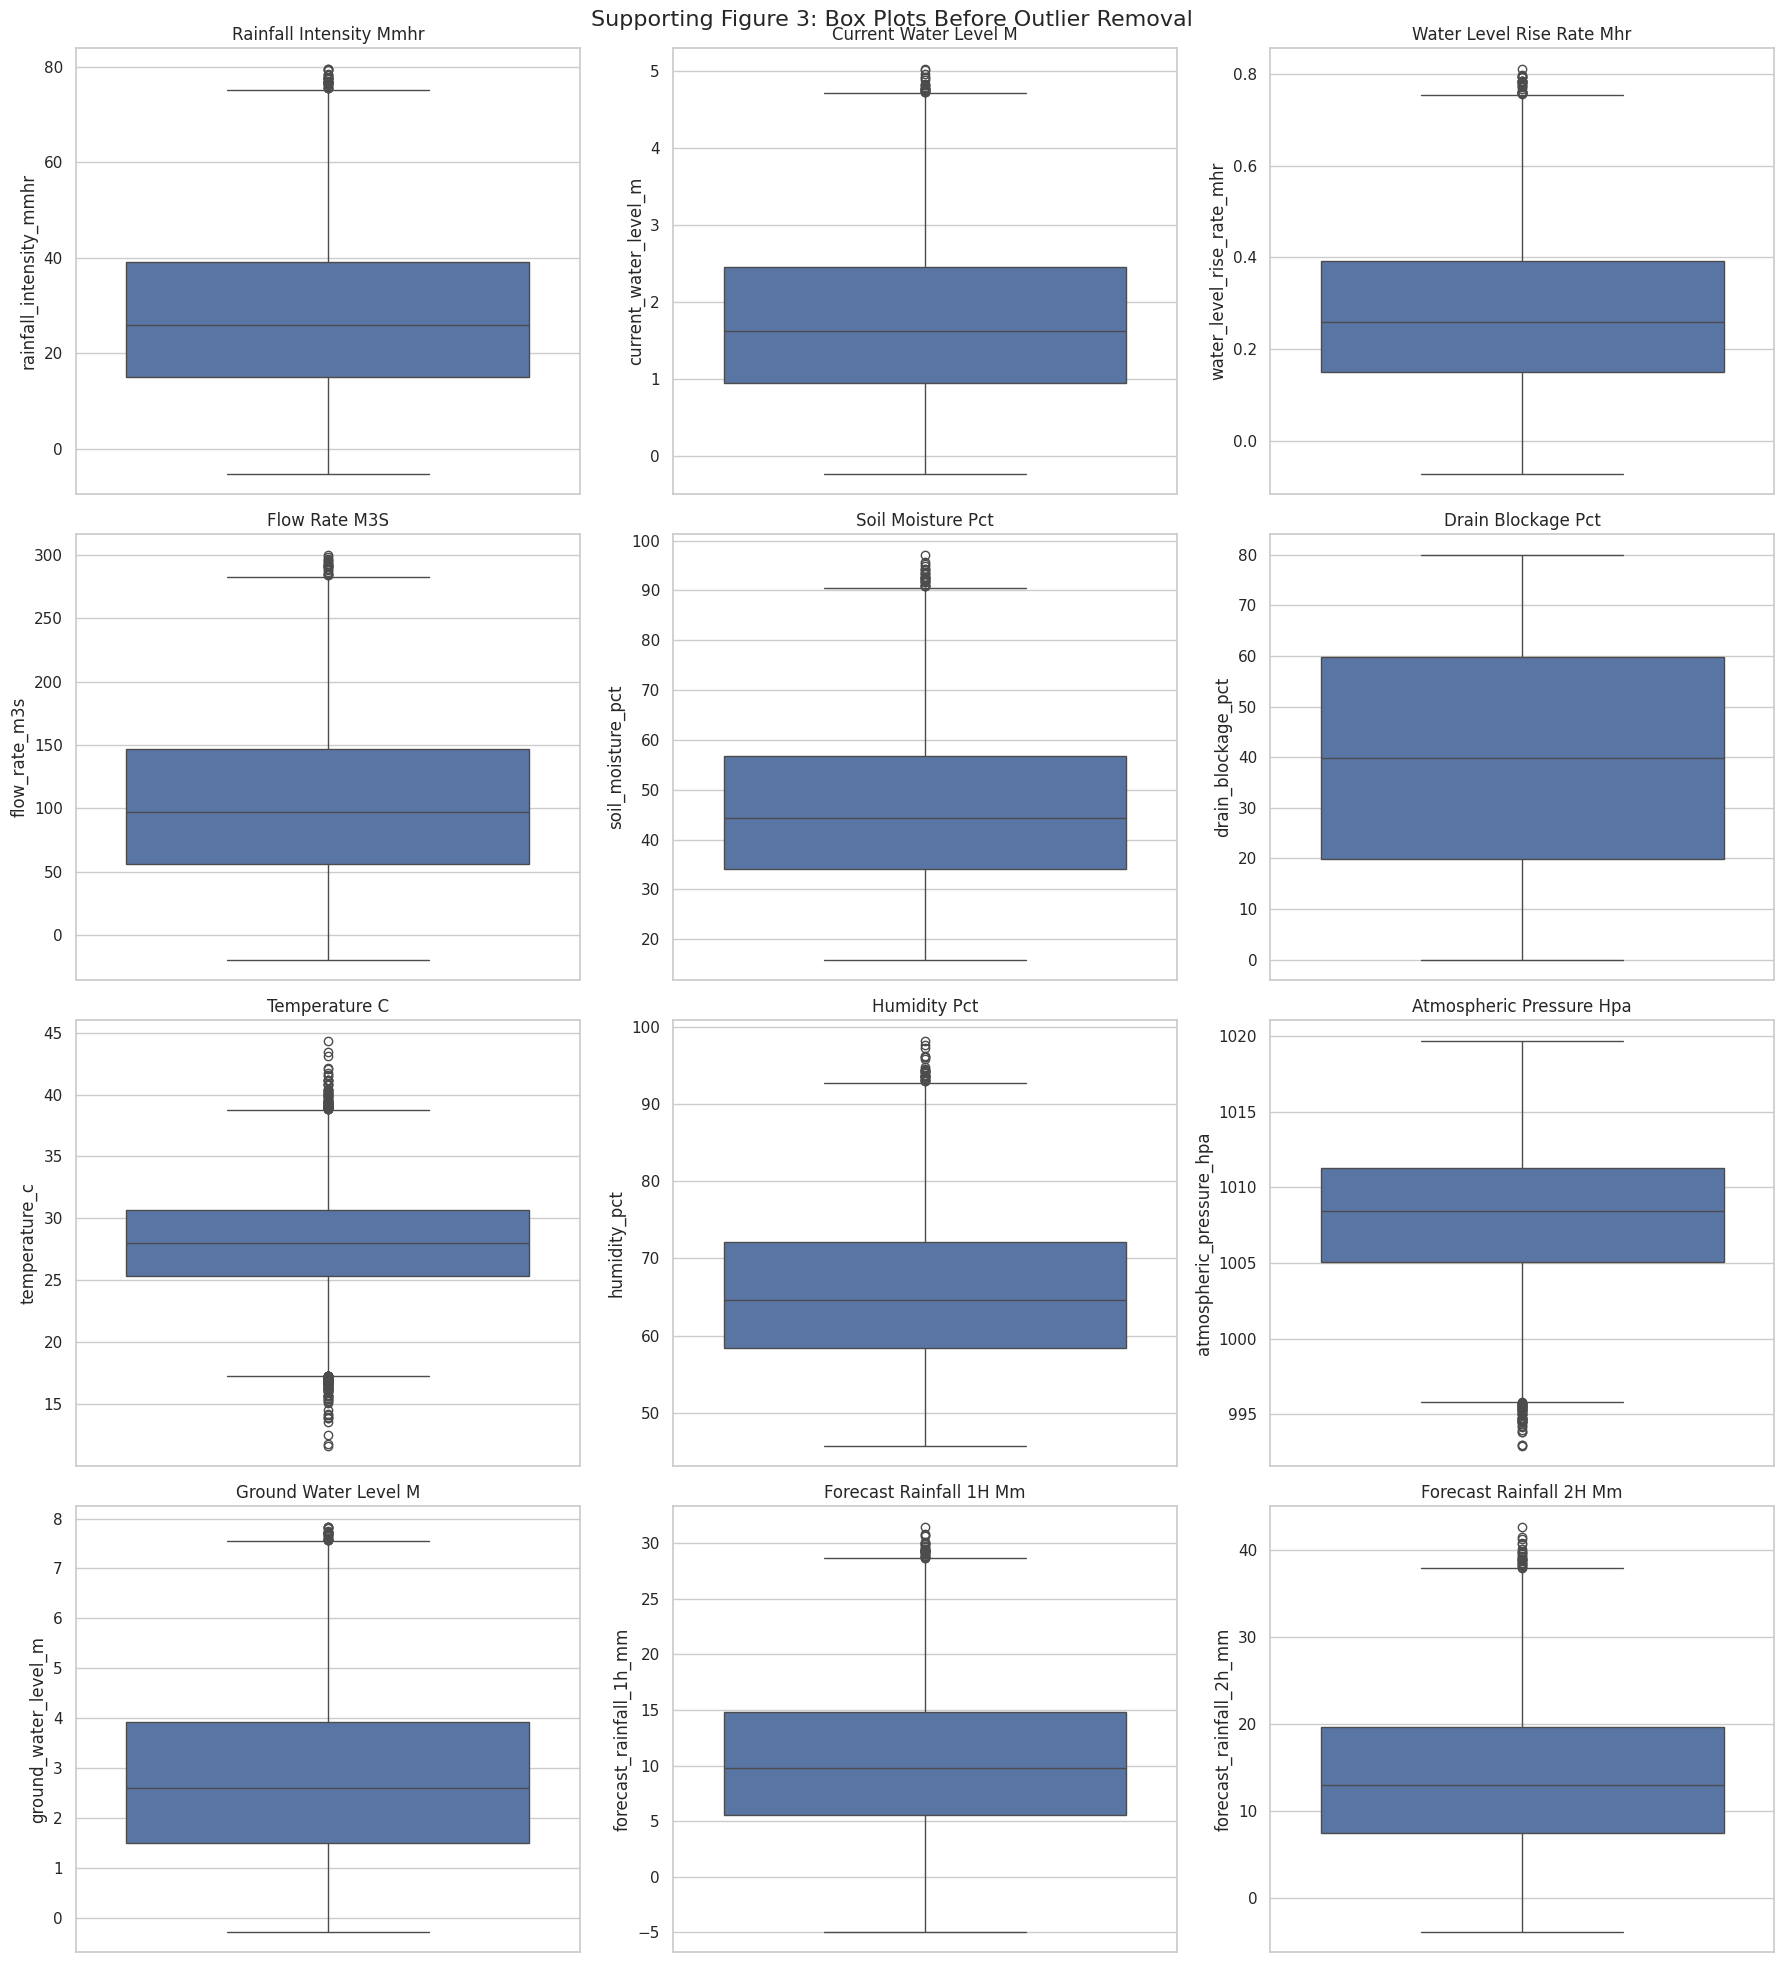

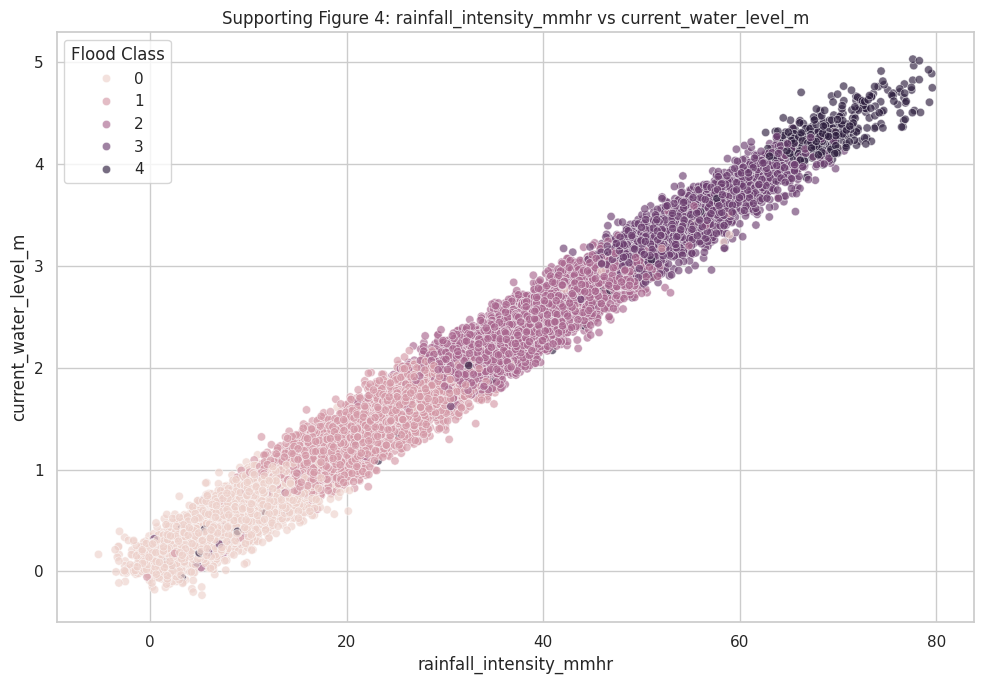

In [9]:
print("\n4. OUTLIER ANALYSIS")

if len(numeric_feature_names) > 0:

    box_features = numeric_feature_names[:min(12, len(numeric_feature_names))]

    n_cols = 3
    n_rows = int(np.ceil(len(box_features) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(axes, box_features):

        sns.boxplot(
            y=df[feature],
            ax=ax
        )

        ax.set_title(
            feature.replace("_", " ").title()
        )

    for ax in axes[len(box_features):]:
        ax.axis("off")

    plt.suptitle(
        "Supporting Figure 3: Box Plots Before Outlier Removal",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# SCATTER PLOT
# ============================================================

if len(numeric_feature_names) >= 2:

    scatter_x = numeric_feature_names[0]
    scatter_y = numeric_feature_names[1]

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=df,
        x=scatter_x,
        y=scatter_y,
        hue=TARGET_COLUMN,
        hue_order=classes,
        alpha=0.65
    )

    plt.title(
        f"Supporting Figure 4: {scatter_x} vs {scatter_y}"
    )

    plt.xlabel(scatter_x)
    plt.ylabel(scatter_y)
    plt.legend(
        title="Flood Class"
    )

    plt.tight_layout()
    plt.show()

TRAIN TEST SPLIT


In [10]:
print("\n5. TRAIN / TEST SPLIT")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training Samples:", len(X_train_raw))
print("Testing Samples:", len(X_test_raw))

print("\nTraining Class Distribution:")
display(
    y_train.value_counts()
    .sort_index()
    .to_frame("Count")
)

print("\nTesting Class Distribution:")
display(
    y_test.value_counts()
    .sort_index()
    .to_frame("Count")
)



5. TRAIN / TEST SPLIT
Training Samples: 16000
Testing Samples: 4000

Training Class Distribution:


,Count
flood_severity_stage,
0,3779
1,5640
2,4351
3,1905
4,325



Testing Class Distribution:


,Count
flood_severity_stage,
0,945
1,1410
2,1088
3,476
4,81


 MISSING VALUE HANDLING

In [11]:
print("\n6. MISSING VALUE HANDLING")

numeric_imputer = SimpleImputer(strategy="median")

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_train_numeric = pd.DataFrame(
    numeric_imputer.fit_transform(
        X_train_raw[numeric_feature_names]
    ),
    columns=numeric_feature_names,
    index=X_train_raw.index
)

X_test_numeric = pd.DataFrame(
    numeric_imputer.transform(
        X_test_raw[numeric_feature_names]
    ),
    columns=numeric_feature_names,
    index=X_test_raw.index
)

if len(categorical_feature_names) > 0:

    X_train_categorical = pd.DataFrame(
        categorical_imputer.fit_transform(
            X_train_raw[categorical_feature_names]
        ),
        columns=categorical_feature_names,
        index=X_train_raw.index
    )

    X_test_categorical = pd.DataFrame(
        categorical_imputer.transform(
            X_test_raw[categorical_feature_names]
        ),
        columns=categorical_feature_names,
        index=X_test_raw.index
    )

else:

    X_train_categorical = pd.DataFrame(
        index=X_train_raw.index
    )

    X_test_categorical = pd.DataFrame(
        index=X_test_raw.index
    )



6. MISSING VALUE HANDLING


 OUTLIER DETECTION ON TRAINING DATA ONLY


7. OUTLIER DETECTION USING TRAINING DATA ONLY
Training Rows Before Outlier Removal: 16000
IQR Outlier Rows: 596
Z-score Outlier Rows: 109
Rows Identified by Either Method: 596
Training Rows After Outlier Removal: 15404
Rows Removed: 596


,Feature,IQR_Outliers,ZScore_Outliers
0,rainfall_intensity_mmhr,28,0
1,current_water_level_m,15,0
2,water_level_rise_rate_mhr,21,0
3,flow_rate_m3s,16,0
4,soil_moisture_pct,21,0
5,drain_blockage_pct,0,0
6,temperature_c,121,9
7,humidity_pct,27,0
8,atmospheric_pressure_hpa,34,1
9,ground_water_level_m,17,0



Table 2: Missing Values and Outlier Analysis


,Measure,Value
0,Rows Before Outlier Removal,16000
1,IQR Outlier Rows,596
2,Z-score Outlier Rows,109
3,Rows Identified by Either Method,596
4,Rows After Outlier Removal,15404
5,Rows Removed,596


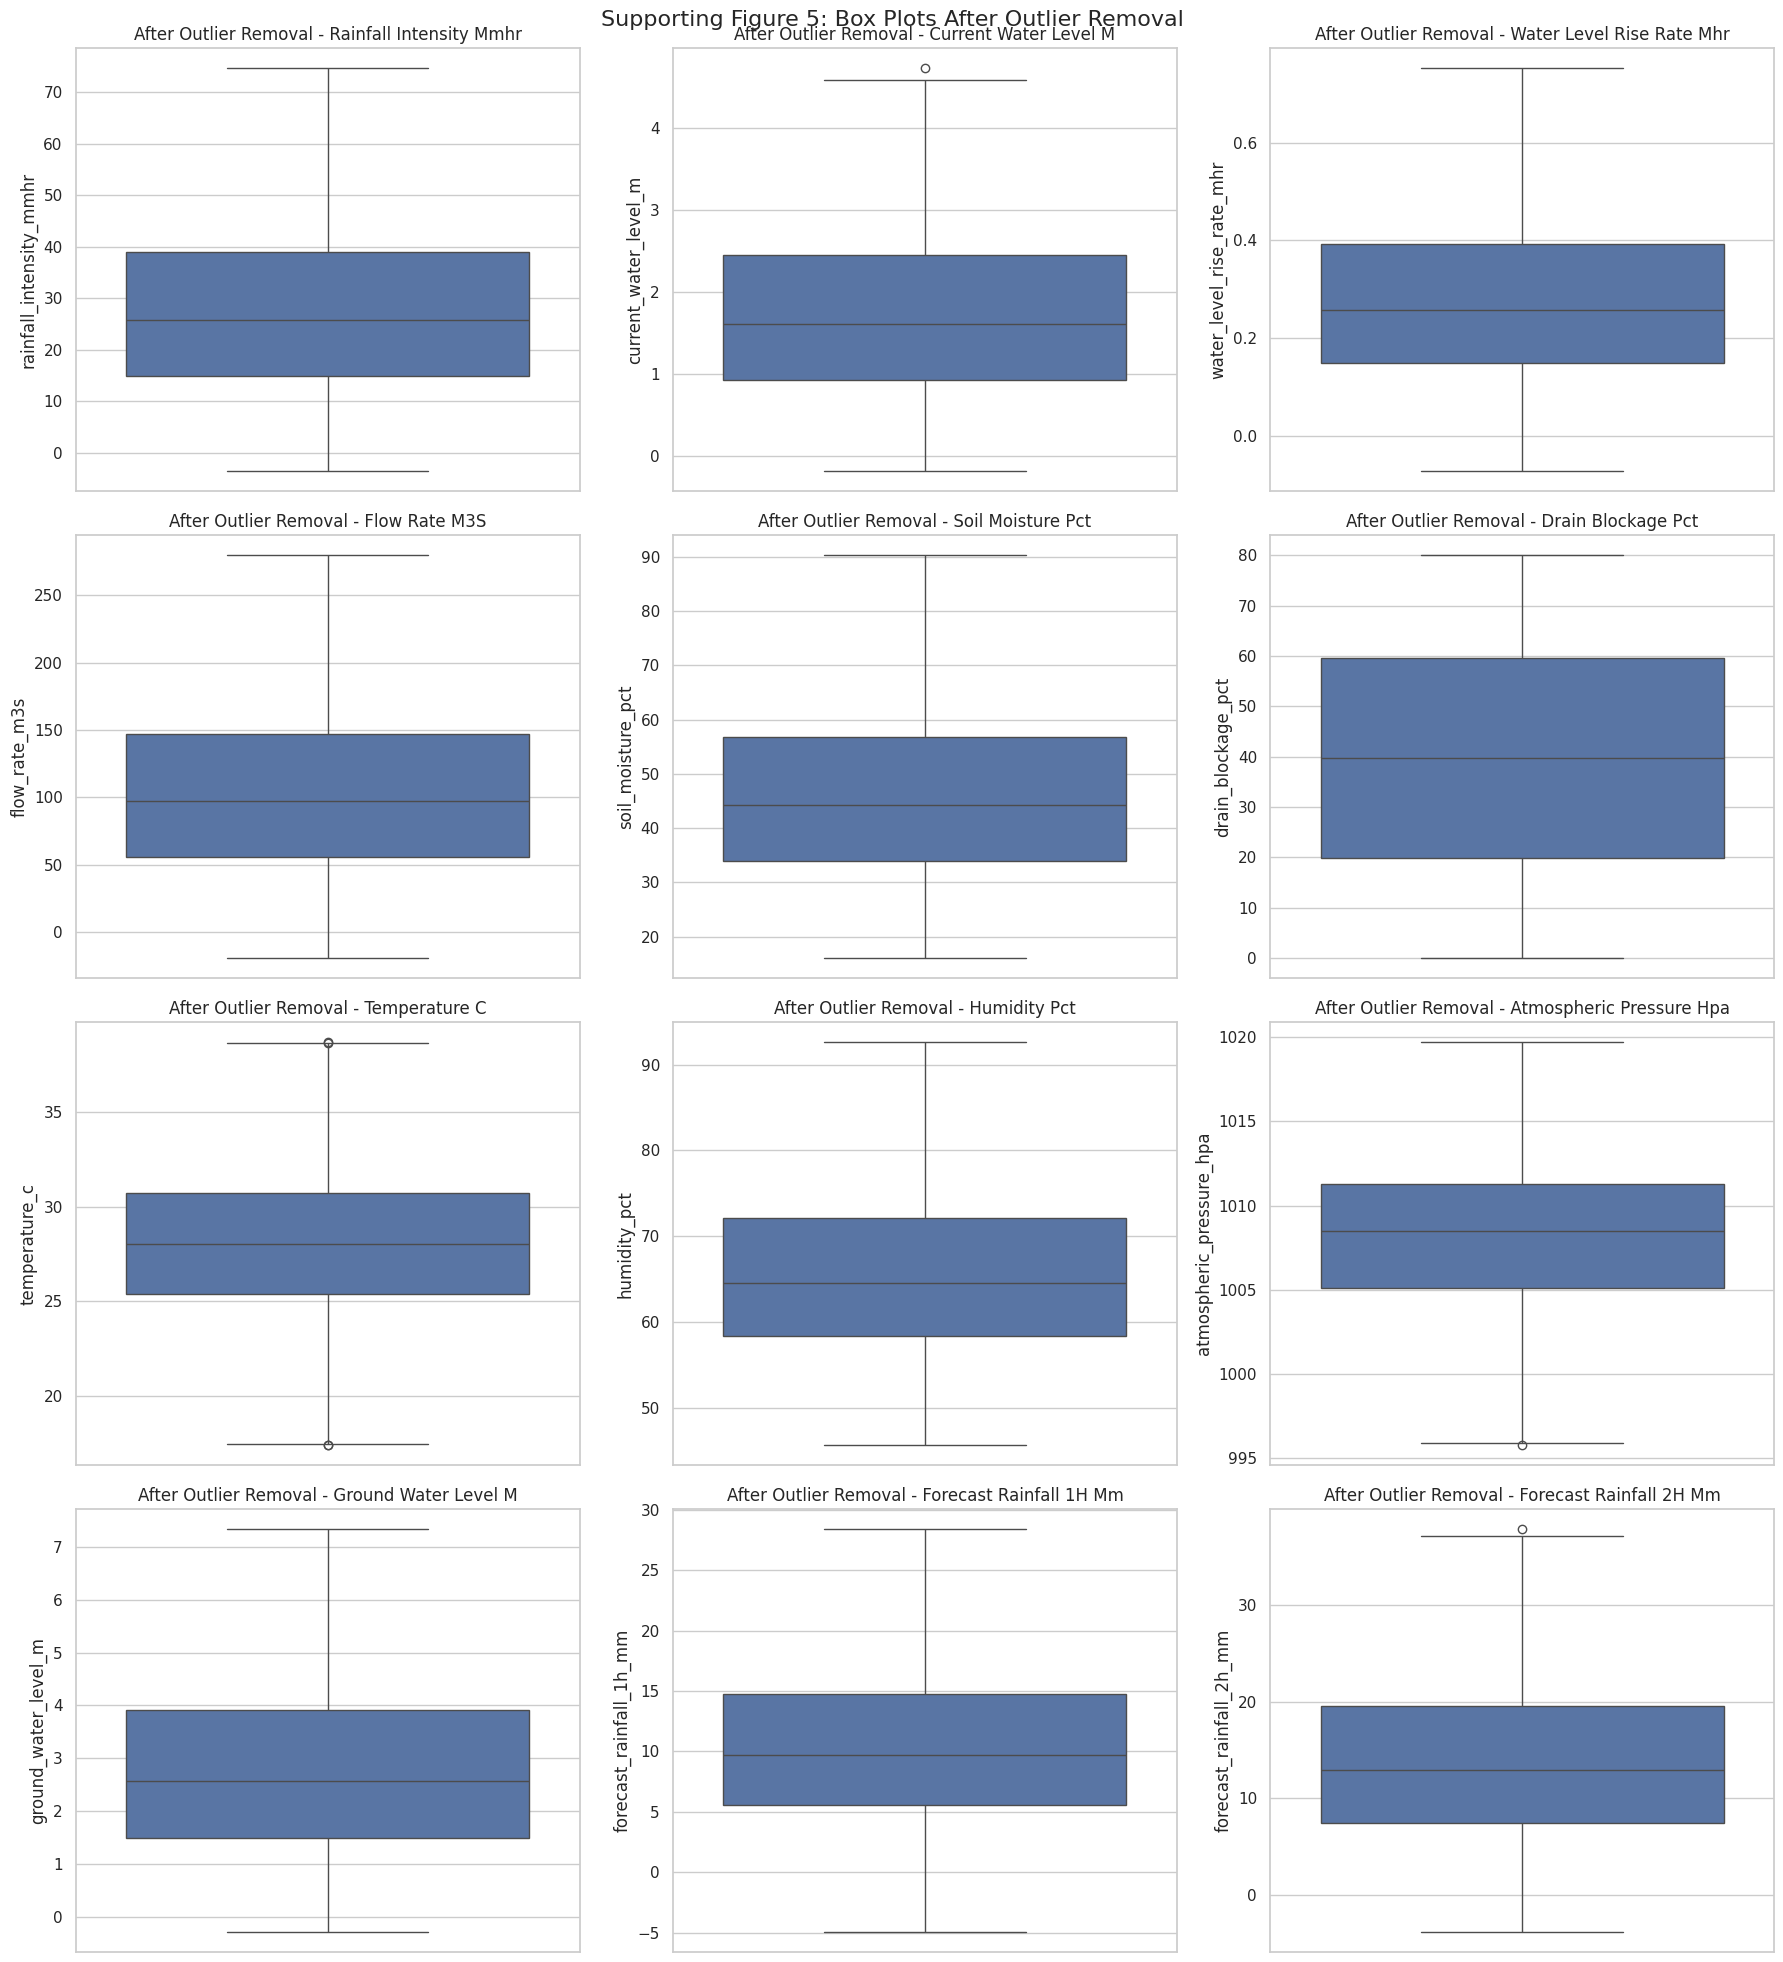

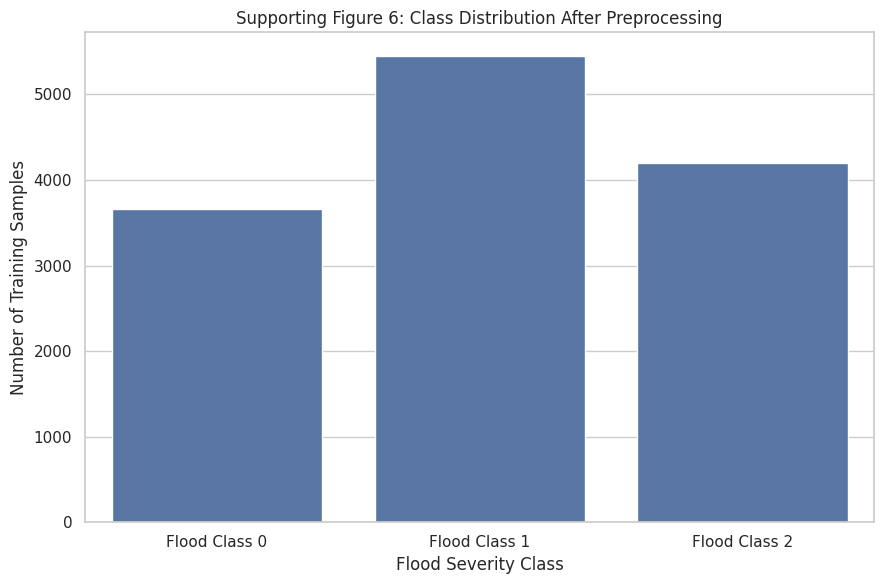

In [12]:
print("\n7. OUTLIER DETECTION USING TRAINING DATA ONLY")

iqr_outlier_mask = np.zeros(
    len(X_train_numeric),
    dtype=bool
)

zscore_outlier_mask = np.zeros(
    len(X_train_numeric),
    dtype=bool
)

iqr_counts = {}
zscore_counts = {}

for feature in numeric_feature_names:

    values = X_train_numeric[feature]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    feature_iqr_mask = (
        (values < lower_bound) |
        (values > upper_bound)
    )

    iqr_counts[feature] = feature_iqr_mask.sum()

    iqr_outlier_mask |= feature_iqr_mask.values


for feature in numeric_feature_names:

    values = X_train_numeric[feature]

    mean_value = values.mean()
    std_value = values.std(ddof=0)

    if std_value == 0:

        feature_z_mask = np.zeros(
            len(values),
            dtype=bool
        )

    else:

        z_values = np.abs(
            (values - mean_value) / std_value
        )

        feature_z_mask = z_values > 3.5

    zscore_counts[feature] = feature_z_mask.sum()

    zscore_outlier_mask |= feature_z_mask.values


combined_outlier_mask = (
    iqr_outlier_mask |
    zscore_outlier_mask
)

print("Training Rows Before Outlier Removal:", len(X_train_raw))
print("IQR Outlier Rows:", iqr_outlier_mask.sum())
print("Z-score Outlier Rows:", zscore_outlier_mask.sum())
print(
    "Rows Identified by Either Method:",
    combined_outlier_mask.sum()
)

X_train_clean = X_train_numeric.loc[
    ~combined_outlier_mask
].copy()

y_train_clean = y_train.loc[
    X_train_clean.index
].copy()

if len(categorical_feature_names) > 0:

    X_train_cat_clean = X_train_categorical.loc[
        X_train_clean.index
    ].copy()

else:

    X_train_cat_clean = pd.DataFrame(
        index=X_train_clean.index
    )

print(
    "Training Rows After Outlier Removal:",
    len(X_train_clean)
)

print(
    "Rows Removed:",
    len(X_train_raw) - len(X_train_clean)
)

outlier_table = pd.DataFrame({
    "Feature": numeric_feature_names,
    "IQR_Outliers": [
        iqr_counts[f]
        for f in numeric_feature_names
    ],
    "ZScore_Outliers": [
        zscore_counts[f]
        for f in numeric_feature_names
    ]
})

display(outlier_table)


# ============================================================
# OUTLIER TABLE
# ============================================================

table_2 = pd.DataFrame({
    "Measure": [
        "Rows Before Outlier Removal",
        "IQR Outlier Rows",
        "Z-score Outlier Rows",
        "Rows Identified by Either Method",
        "Rows After Outlier Removal",
        "Rows Removed"
    ],
    "Value": [
        len(X_train_raw),
        iqr_outlier_mask.sum(),
        zscore_outlier_mask.sum(),
        combined_outlier_mask.sum(),
        len(X_train_clean),
        len(X_train_raw) - len(X_train_clean)
    ]
})

print("\nTable 2: Missing Values and Outlier Analysis")
display(table_2)


# ============================================================
# BOX PLOTS AFTER OUTLIER REMOVAL
# ============================================================

if len(numeric_feature_names) > 0:

    box_features_after = numeric_feature_names[
        :min(12, len(numeric_feature_names))
    ]

    n_cols = 3
    n_rows = int(
        np.ceil(len(box_features_after) / n_cols)
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(
        axes,
        box_features_after
    ):

        sns.boxplot(
            y=X_train_clean[feature],
            ax=ax
        )

        ax.set_title(
            "After Outlier Removal - " +
            feature.replace("_", " ").title()
        )

    for ax in axes[len(box_features_after):]:
        ax.axis("off")

    plt.suptitle(
        "Supporting Figure 5: Box Plots After Outlier Removal",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# CLASS DISTRIBUTION AFTER PREPROCESSING
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    x=y_train_clean,
    order=classes
)

plt.title(
    "Supporting Figure 6: Class Distribution After Preprocessing"
)

plt.xlabel("Flood Severity Class")
plt.ylabel("Number of Training Samples")

plt.xticks(
    range(len(classes)),
    [f"Flood Class {c}" for c in classes]
)

plt.tight_layout()
plt.show()



CORRELATION FEATURE SELECTION


8. CORRELATION-BASED FEATURE SELECTION

Correlation Matrix of Input Features


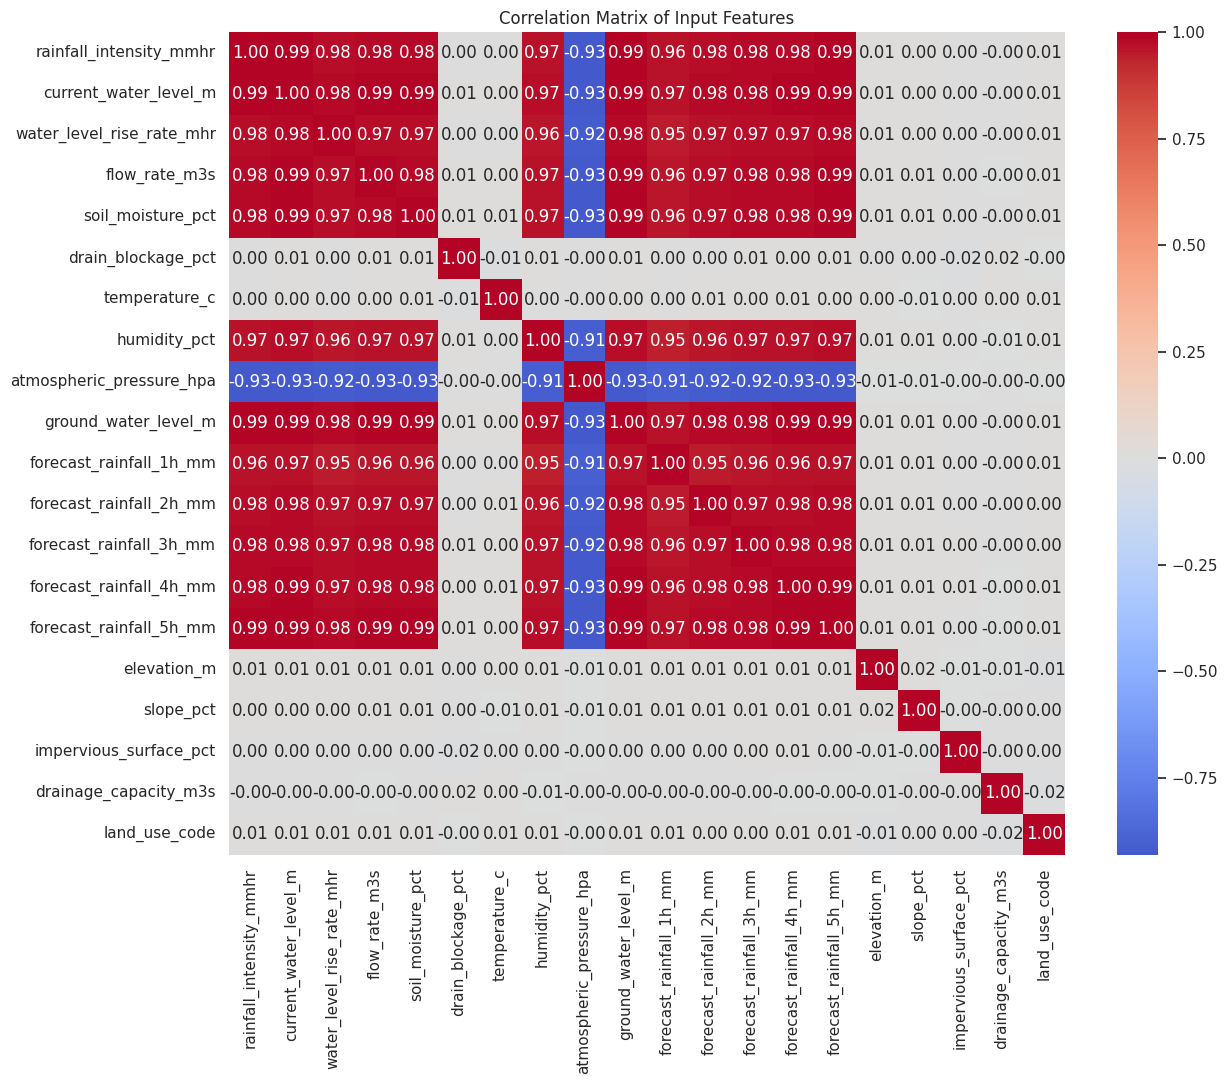

Original Numerical Features: 20
Removed Highly Correlated Features: 12
Selected Numerical Features: 8

Removed Features:
['current_water_level_m', 'water_level_rise_rate_mhr', 'flow_rate_m3s', 'soil_moisture_pct', 'humidity_pct', 'atmospheric_pressure_hpa', 'ground_water_level_m', 'forecast_rainfall_1h_mm', 'forecast_rainfall_2h_mm', 'forecast_rainfall_3h_mm', 'forecast_rainfall_4h_mm', 'forecast_rainfall_5h_mm']

Selected Features:
rainfall_intensity_mmhr
drain_blockage_pct
temperature_c
elevation_m
slope_pct
impervious_surface_pct
drainage_capacity_m3s
land_use_code

Categorical Features Retained: ['land_use_name']

Correlation Matrix of Selected Features


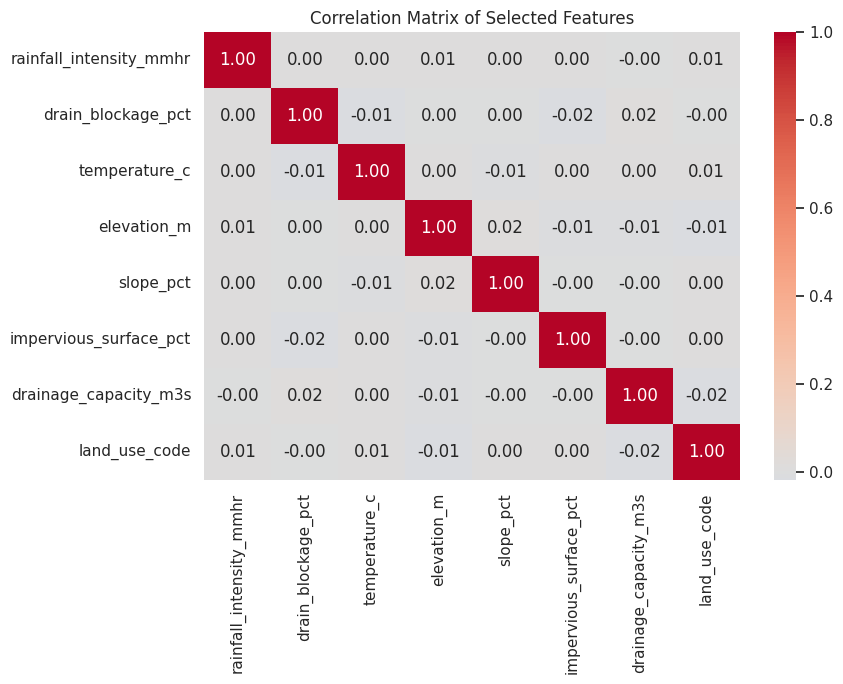

In [15]:
print("\n8. CORRELATION-BASED FEATURE SELECTION")

if len(numeric_feature_names) == 0:
    raise ValueError(
        "At least one numerical feature is required."
    )

correlation_matrix = X_train_clean.corr()

print("\nCorrelation Matrix of Input Features")

plt.figure(
    figsize=(
        max(10, len(numeric_feature_names) * 0.65),
        max(8, len(numeric_feature_names) * 0.55)
    )
)

sns.heatmap(
    correlation_matrix,
    annot=len(numeric_feature_names) <= 20,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False
)

plt.title(
    "Correlation Matrix of Input Features"
)

plt.tight_layout()
plt.show()


# ============================================================
# REMOVE HIGHLY CORRELATED FEATURES
# ============================================================

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(
            correlation_matrix.shape
        ),
        k=1
    ).astype(bool)
)

correlated_features = [
    column
    for column in upper_triangle.columns
    if any(
        abs(upper_triangle[column]) >
        CORRELATION_THRESHOLD
    )
]

selected_numeric_features = [
    feature
    for feature in numeric_feature_names
    if feature not in correlated_features
]

if len(selected_numeric_features) == 0:

    selected_numeric_features = [
        numeric_feature_names[0]
    ]

print(
    "Original Numerical Features:",
    len(numeric_feature_names)
)

print(
    "Removed Highly Correlated Features:",
    len(correlated_features)
)

print(
    "Selected Numerical Features:",
    len(selected_numeric_features)
)

print("\nRemoved Features:")
print(correlated_features)

print("\nSelected Features:")
for feature in selected_numeric_features:
    print(feature)


# ============================================================
# CATEGORICAL FEATURES
# ============================================================

selected_categorical_features = categorical_feature_names.copy()

if len(selected_categorical_features) > 0:

    print(
        "\nCategorical Features Retained:",
        selected_categorical_features
    )


# ============================================================
# SELECTED DATA
# ============================================================

X_train_selected_numeric = X_train_clean[
    selected_numeric_features
].copy()

X_test_selected_numeric = X_test_numeric[
    selected_numeric_features
].copy()

if len(selected_categorical_features) > 0:

    X_train_selected_categorical = X_train_cat_clean[
        selected_categorical_features
    ].copy()

    X_test_selected_categorical = X_test_categorical[
        selected_categorical_features
    ].copy()

else:

    X_train_selected_categorical = pd.DataFrame(
        index=X_train_selected_numeric.index
    )

    X_test_selected_categorical = pd.DataFrame(
        index=X_test_selected_numeric.index
    )


# ============================================================
# CORRELATION MATRIX AFTER SELECTION
# ============================================================

print("\nCorrelation Matrix of Selected Features")

selected_corr = X_train_selected_numeric.corr()

plt.figure(
    figsize=(
        max(9, len(selected_numeric_features) * 0.7),
        max(7, len(selected_numeric_features) * 0.6)
    )
)

sns.heatmap(
    selected_corr,
    annot=len(selected_numeric_features) <= 20,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Selected Features"
)

plt.tight_layout()
plt.show()


 ENCODE CATEGORICAL VARIABLES

In [16]:
print("\n9. CATEGORICAL ENCODING")

if len(selected_categorical_features) > 0:

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    X_train_cat_encoded = encoder.fit_transform(
        X_train_selected_categorical
    )

    X_test_cat_encoded = encoder.transform(
        X_test_selected_categorical
    )

    encoded_categorical_names = (
        encoder.get_feature_names_out(
            selected_categorical_features
        ).tolist()
    )

else:

    X_train_cat_encoded = np.empty(
        (len(X_train_selected_numeric), 0)
    )

    X_test_cat_encoded = np.empty(
        (len(X_test_selected_numeric), 0)
    )

    encoded_categorical_names = []


X_train_feature_matrix = np.hstack([
    X_train_selected_numeric.values,
    X_train_cat_encoded
])

X_test_feature_matrix = np.hstack([
    X_test_selected_numeric.values,
    X_test_cat_encoded
])

all_selected_feature_names = (
    selected_numeric_features +
    encoded_categorical_names
)

print(
    "Final Feature Count Before PCA:",
    len(all_selected_feature_names)
)



9. CATEGORICAL ENCODING
Final Feature Count Before PCA: 14


 SCALING

In [17]:
print("\n10. FEATURE SCALING")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_feature_matrix
)

X_test_scaled = scaler.transform(
    X_test_feature_matrix
)

print(
    "Scaled Training Matrix:",
    X_train_scaled.shape
)

print(
    "Scaled Testing Matrix:",
    X_test_scaled.shape
)




10. FEATURE SCALING
Scaled Training Matrix: (15404, 14)
Scaled Testing Matrix: (4000, 14)


 PCA


11. PCA ANALYSIS
PCA Components Required for 95% Variance: 12
Total Explained Variance: 1.0


,Component,Individual_Explained_Variance,Cumulative_Explained_Variance
0,1,0.157308,0.157308
1,2,0.086408,0.243716
2,3,0.085963,0.329679
3,4,0.085768,0.415447
4,5,0.085467,0.500914
5,6,0.073461,0.574376
6,7,0.072873,0.647249
7,8,0.071693,0.718942
8,9,0.071116,0.790058
9,10,0.070908,0.860966


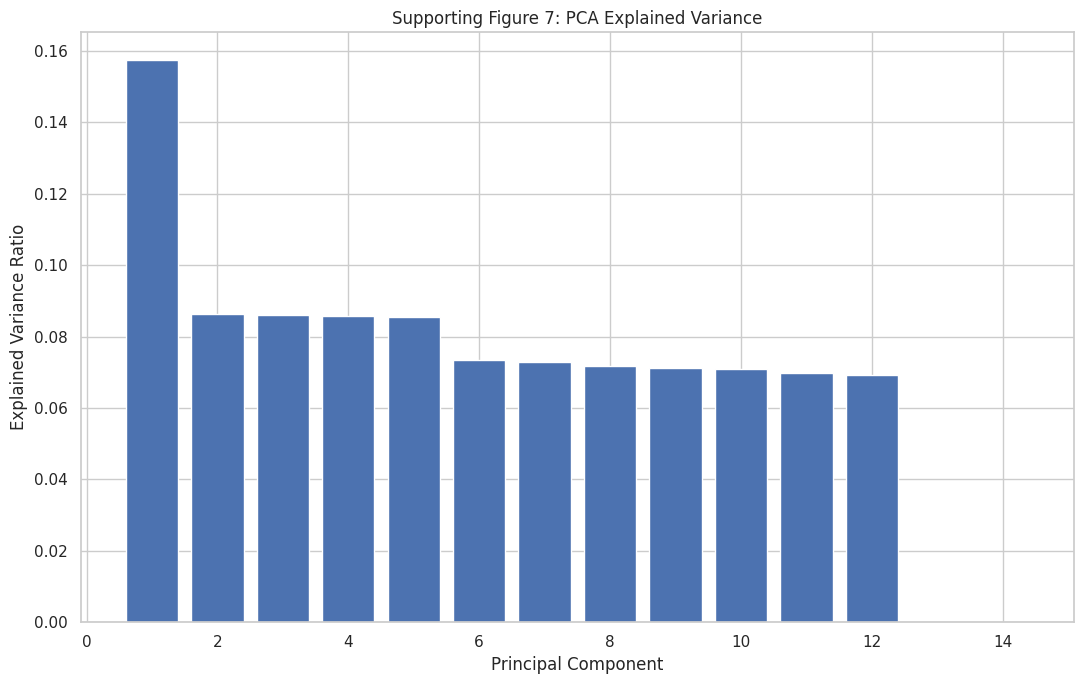

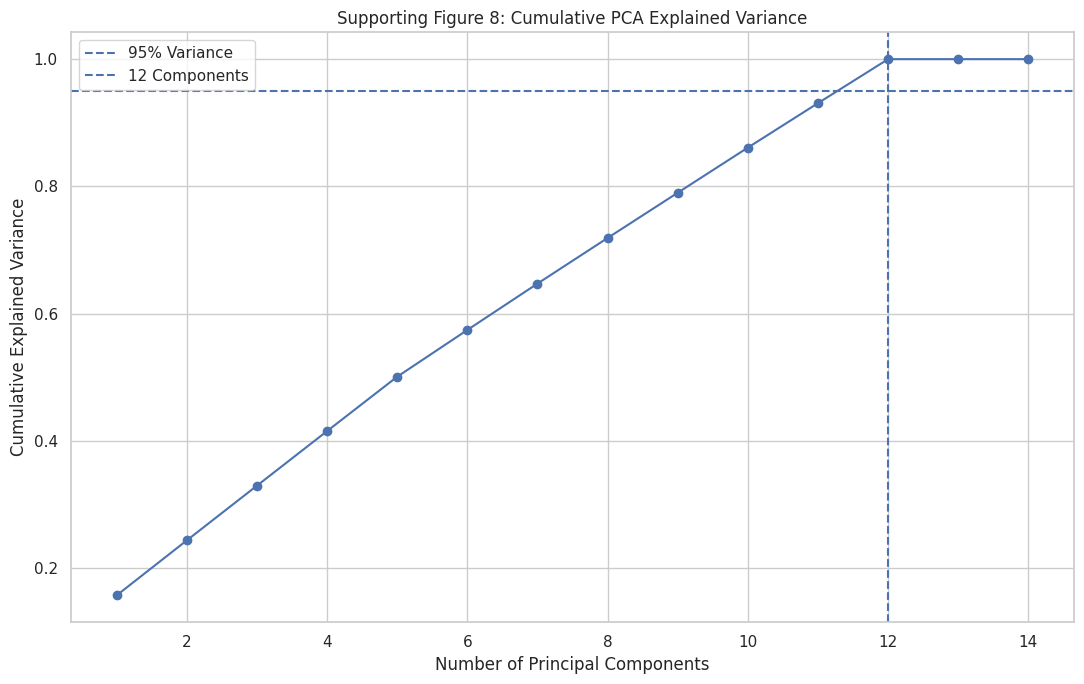


Table 3: Feature Selection and PCA Summary


,Measure,Value
0,Original Numerical Features,20.0
1,Removed Correlated Features,12.0
2,Selected Numerical Features,8.0
3,Categorical Features,1.0
4,Encoded Feature Count,14.0
5,PCA Components,12.0
6,PCA Explained Variance,1.0


In [18]:
print("\n11. PCA ANALYSIS")

pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(
    X_train_scaled
)

individual_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    individual_variance
)

pca_components = (
    np.argmax(
        cumulative_variance >= PCA_VARIANCE
    ) + 1
)

pca_components = max(
    1,
    min(
        pca_components,
        X_train_scaled.shape[1]
    )
)

pca = PCA(
    n_components=pca_components
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print(
    "PCA Components Required for 95% Variance:",
    pca_components
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

pca_variance_table = pd.DataFrame({
    "Component": np.arange(
        1,
        len(individual_variance) + 1
    ),
    "Individual_Explained_Variance":
        individual_variance,
    "Cumulative_Explained_Variance":
        cumulative_variance
})

display(
    pca_variance_table.head(
        pca_components
    )
)


# ============================================================
# PCA EXPLAINED VARIANCE
# ============================================================

plt.figure(figsize=(11, 7))

plt.bar(
    range(
        1,
        len(individual_variance) + 1
    ),
    individual_variance
)

plt.title(
    "Supporting Figure 7: PCA Explained Variance"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.tight_layout()
plt.show()


# ============================================================
# CUMULATIVE PCA VARIANCE
# ============================================================

plt.figure(figsize=(11, 7))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    PCA_VARIANCE,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    pca_components,
    linestyle="--",
    label=f"{pca_components} Components"
)

plt.title(
    "Supporting Figure 8: Cumulative PCA Explained Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# TABLE 3
# ============================================================

table_3 = pd.DataFrame({
    "Measure": [
        "Original Numerical Features",
        "Removed Correlated Features",
        "Selected Numerical Features",
        "Categorical Features",
        "Encoded Feature Count",
        "PCA Components",
        "PCA Explained Variance"
    ],
    "Value": [
        len(numeric_feature_names),
        len(correlated_features),
        len(selected_numeric_features),
        len(selected_categorical_features),
        len(all_selected_feature_names),
        pca_components,
        pca.explained_variance_ratio_.sum()
    ]
})

print(
    "\nTable 3: Feature Selection and PCA Summary"
)

display(table_3)


 MODEL DEFINITIONS

In [19]:
print("\n12. MODEL CONFIGURATION")


def build_primary_models():

    models = {

        "SVM-RBF": SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=350,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.85,
            colsample_bytree=0.90,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=11,
            weights="distance",
            metric="minkowski",
            p=2
        ),

        "Logistic Regression": LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=3000,
            class_weight="balanced"
        )
    }

    return models


def build_additional_models():

    models = {

        "Extra Trees": ExtraTreesClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_split=3,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.85,
            random_state=RANDOM_STATE
        ),

        "Hist Gradient Boosting": HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.5,
            random_state=RANDOM_STATE
        ),

        "Gaussian Naive Bayes": GaussianNB()
    }

    return models


# ============================================================
# MODEL INPUT STRATEGY
# ============================================================

tree_models = [
    "Random Forest",
    "XGBoost",
    "Extra Trees",
    "Gradient Boosting",
    "Hist Gradient Boosting"
]

scaled_models = [
    "SVM-RBF",
    "KNN",
    "Logistic Regression",
    "Gaussian Naive Bayes"
]


def get_model_input(
    model_name,
    X_original,
    X_pca
):

    if model_name in scaled_models:
        return X_pca

    return X_original


# ============================================================
# MODEL TUNING
# ============================================================

print("\n13. MODEL-SPECIFIC HYPERPARAMETER TUNING")


def tune_primary_models():

    tuned_models = {}

    cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=1,
        random_state=RANDOM_STATE
    )

    models = build_primary_models()

    parameter_spaces = {

        "SVM-RBF": {
            "C": [0.1, 0.5, 1, 2, 5, 10, 20],
            "gamma": [
                "scale",
                "auto",
                0.001,
                0.01,
                0.05,
                0.1
            ]
        },

        "Random Forest": {
            "n_estimators": [
                250,
                400,
                600
            ],
            "max_depth": [
                None,
                8,
                12,
                20
            ],
            "min_samples_split": [
                2,
                4,
                8
            ],
            "min_samples_leaf": [
                1,
                2,
                4
            ],
            "max_features": [
                "sqrt",
                "log2"
            ]
        },

        "XGBoost": {
            "n_estimators": [
                200,
                300,
                450
            ],
            "learning_rate": [
                0.03,
                0.05,
                0.1
            ],
            "max_depth": [
                3,
                4,
                5,
                6
            ],
            "subsample": [
                0.75,
                0.85,
                1.0
            ],
            "colsample_bytree": [
                0.75,
                0.9,
                1.0
            ]
        },

        "KNN": {
            "n_neighbors": [
                3,
                5,
                7,
                9,
                11,
                15,
                21
            ],
            "weights": [
                "uniform",
                "distance"
            ],
            "metric": [
                "euclidean",
                "manhattan"
            ]
        },

        "Logistic Regression": {
            "C": [
                0.01,
                0.1,
                0.5,
                1,
                2,
                5,
                10
            ],
            "solver": [
                "lbfgs",
                "newton-cg"
            ]
        }
    }

    for model_name, model in models.items():

        print(
            f"\nTuning {model_name}..."
        )

        X_input = get_model_input(
            model_name,
            X_train_feature_matrix,
            X_train_pca
        )

        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=parameter_spaces[
                model_name
            ],
            n_iter=12,
            scoring="f1_macro",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True
        )

        search.fit(
            X_input,
            y_train_clean
        )

        tuned_models[model_name] = search.best_estimator_

        print(
            "Best CV F1:",
            round(search.best_score_, 4)
        )

        print(
            "Best Parameters:",
            search.best_params_
        )

    return tuned_models


tuned_primary_models = tune_primary_models()




12. MODEL CONFIGURATION

13. MODEL-SPECIFIC HYPERPARAMETER TUNING

Tuning SVM-RBF...
Best CV F1: 0.7917
Best Parameters: {'gamma': 0.01, 'C': 20}

Tuning Random Forest...
Best CV F1: 0.8061
Best Parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 8}

Tuning XGBoost...
Best CV F1: 0.8193
Best Parameters: {'subsample': 0.75, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}

Tuning KNN...
Best CV F1: 0.5814
Best Parameters: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'euclidean'}

Tuning Logistic Regression...
Best CV F1: 0.6445
Best Parameters: {'solver': 'newton-cg', 'C': 2}


 METRIC FUNCTIONS

In [20]:
print("\n14. METRIC FUNCTIONS")


def calculate_specificity(
    y_true,
    y_pred,
    class_labels
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_labels
    )

    specificity_values = {}

    total = cm.sum()

    for i, class_label in enumerate(
        class_labels
    ):

        tp = cm[i, i]

        fn = (
            cm[i, :].sum() -
            tp
        )

        fp = (
            cm[:, i].sum() -
            tp
        )

        tn = (
            total -
            tp -
            fn -
            fp
        )

        denominator = tn + fp

        specificity_values[
            class_label
        ] = (
            tn / denominator
            if denominator > 0
            else np.nan
        )

    return specificity_values


def calculate_metrics(
    y_true,
    y_pred,
    y_prob=None
):

    result = {}

    result["Accuracy"] = accuracy_score(
        y_true,
        y_pred
    )

    result["Macro Precision"] = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    result["Macro Recall"] = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    result["Macro F1"] = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    result["Weighted Precision"] = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result["Weighted Recall"] = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result["Weighted F1"] = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result["Balanced Accuracy"] = balanced_accuracy_score(
        y_true,
        y_pred
    )

    result["MCC"] = matthews_corrcoef(
        y_true,
        y_pred
    )

    specificity = calculate_specificity(
        y_true,
        y_pred,
        classes
    )

    result["Specificity"] = np.nanmean(
        list(specificity.values())
    )

    result["Sensitivity"] = result[
        "Macro Recall"
    ]

    if y_prob is not None:

        try:

            result["ROC-AUC"] = roc_auc_score(
                y_true,
                y_prob,
                multi_class="ovr",
                average="macro",
                labels=classes
            )

        except Exception:

            result["ROC-AUC"] = np.nan

    else:

        result["ROC-AUC"] = np.nan

    return result


def classwise_metrics(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    records = []

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=classes
    )

    for i, class_label in enumerate(
        classes
    ):

        tp = cm[i, i]

        fn = (
            cm[i, :].sum() -
            tp
        )

        fp = (
            cm[:, i].sum() -
            tp
        )

        tn = (
            cm.sum() -
            tp -
            fn -
            fp
        )

        precision = (
            tp / (tp + fp)
            if tp + fp > 0
            else 0
        )

        sensitivity = (
            tp / (tp + fn)
            if tp + fn > 0
            else 0
        )

        specificity = (
            tn / (tn + fp)
            if tn + fp > 0
            else 0
        )

        f1 = (
            2 * precision * sensitivity /
            (precision + sensitivity)
            if precision + sensitivity > 0
            else 0
        )

        class_auc = np.nan

        if y_prob is not None:

            binary_true = (
                y_true == class_label
            ).astype(int)

            try:

                class_auc = roc_auc_score(
                    binary_true,
                    y_prob[:, i]
                )

            except Exception:
                pass

        records.append({
            "Model": model_name,
            "Class": class_label,
            "Precision": precision,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "F1-Score": f1,
            "ROC-AUC": class_auc,
            "Support": tp + fn
        })

    return pd.DataFrame(records)


14. METRIC FUNCTIONS


 20 VALIDATION RUNS

In [21]:
print("\n15. 20 REPEATED STRATIFIED VALIDATION RUNS")

all_models = tuned_primary_models.copy()

validation_splitter = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

validation_records = []
validation_predictions = {}

run_number = 0

for train_indices, validation_indices in validation_splitter.split(
    X_train_feature_matrix,
    y_train_clean
):

    run_number += 1

    X_tr_original = X_train_feature_matrix[
        train_indices
    ]

    X_val_original = X_train_feature_matrix[
        validation_indices
    ]

    X_tr_pca = X_train_pca[
        train_indices
    ]

    X_val_pca = X_train_pca[
        validation_indices
    ]

    y_tr = y_train_clean.iloc[
        train_indices
    ]

    y_val = y_train_clean.iloc[
        validation_indices
    ]

    validation_predictions[
        run_number
    ] = {}

    for model_name, model in all_models.items():

        X_tr = get_model_input(
            model_name,
            X_tr_original,
            X_tr_pca
        )

        X_val = get_model_input(
            model_name,
            X_val_original,
            X_val_pca
        )

        model_instance = model

        model_instance.fit(
            X_tr,
            y_tr
        )

        y_val_pred = model_instance.predict(
            X_val
        )

        y_val_prob = model_instance.predict_proba(
            X_val
        )

        metrics = calculate_metrics(
            y_val,
            y_val_pred,
            y_val_prob
        )

        metrics["Run"] = run_number
        metrics["Model"] = model_name

        validation_records.append(
            metrics
        )

        validation_predictions[
            run_number
        ][model_name] = {
            "indices": validation_indices,
            "y_true": y_val.to_numpy(),
            "y_pred": y_val_pred,
            "probability": y_val_prob
        }

validation_results = pd.DataFrame(
    validation_records
)

print(
    "\nCompleted Validation Runs:",
    validation_results["Run"].nunique()
)



15. 20 REPEATED STRATIFIED VALIDATION RUNS

Completed Validation Runs: 20


 PRIMARY MODEL SUMMARY

In [22]:
validation_summary = (
    validation_results
    .groupby("Model")
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Std_Accuracy=("Accuracy", "std"),
        Mean_Precision=("Macro Precision", "mean"),
        Mean_Recall=("Macro Recall", "mean"),
        Mean_F1=("Macro F1", "mean"),
        Std_F1=("Macro F1", "std"),
        Mean_ROC_AUC=("ROC-AUC", "mean"),
        Mean_Balanced_Accuracy=(
            "Balanced Accuracy",
            "mean"
        ),
        Mean_Sensitivity=("Sensitivity", "mean"),
        Mean_Specificity=("Specificity", "mean"),
        Mean_MCC=("MCC", "mean")
    )
    .sort_values(
        [
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Accuracy"
        ],
        ascending=False
    )
)

print("\nValidation Performance Summary:")
display(
    validation_summary.style.format(
        "{:.4f}"
    )
)


Validation Performance Summary:


,Mean_Accuracy,Std_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Std_F1,Mean_ROC_AUC,Mean_Balanced_Accuracy,Mean_Sensitivity,Mean_Specificity,Mean_MCC
Model,,,,,,,,,,,
XGBoost,0.8891,0.0056,0.8650,0.7967,0.8202,0.0157,nan,0.7967,0.7967,0.9546,0.8474
Random Forest,0.8828,0.0059,0.8330,0.7914,0.8046,0.0148,nan,0.7914,0.7914,0.9533,0.8396
SVM-RBF,0.8717,0.0066,0.7827,0.8096,0.7938,0.0129,nan,0.8096,0.8096,0.9523,0.8249
Logistic Regression,0.7894,0.0069,0.6801,0.6604,0.6466,0.0071,nan,0.6604,0.6604,0.9448,0.7213
KNN,0.7386,0.0067,0.6078,0.5669,0.5786,0.0049,nan,0.5669,0.5669,0.8868,0.6370


CHECK NATURAL MODEL DIFFERENCES

In [23]:
print("\n16. CHECKING NATURAL MODEL PREDICTION DIFFERENCES")

agreement_values = []

for run in range(
    1,
    VALIDATION_RUNS + 1
):

    run_data = validation_predictions[
        run
    ]

    model_names = list(
        run_data.keys()
    )

    for model_a, model_b in itertools.combinations(
        model_names,
        2
    ):

        pred_a = run_data[
            model_a
        ]["y_pred"]

        pred_b = run_data[
            model_b
        ]["y_pred"]

        agreement = np.mean(
            pred_a == pred_b
        )

        agreement_values.append(
            agreement
        )

mean_prediction_agreement = np.mean(
    agreement_values
)

print(
    "Mean Pairwise Prediction Agreement:",
    round(mean_prediction_agreement, 4)
)

if mean_prediction_agreement >= 0.98:

    print(
        "\nPrimary algorithms are producing highly similar predictions."
    )

    print(
        "Additional genuinely different classifiers will be evaluated."
    )

    additional_models = build_additional_models()

    for model_name, model in additional_models.items():

        print(
            f"\nEvaluating Additional Model: {model_name}"
        )

        validation_predictions[
            "additional_" + model_name
        ] = {}

        for run_number in range(
            1,
            VALIDATION_RUNS + 1
        ):

            train_indices, validation_indices = list(
                RepeatedStratifiedKFold(
                    n_splits=N_SPLITS,
                    n_repeats=N_REPEATS,
                    random_state=RANDOM_STATE
                ).split(
                    X_train_feature_matrix,
                    y_train_clean
                )
            )[run_number - 1]

            X_tr_original = X_train_feature_matrix[
                train_indices
            ]

            X_val_original = X_train_feature_matrix[
                validation_indices
            ]

            y_tr = y_train_clean.iloc[
                train_indices
            ]

            y_val = y_train_clean.iloc[
                validation_indices
            ]

            if model_name in scaled_models:

                X_tr = X_train_pca[
                    train_indices
                ]

                X_val = X_train_pca[
                    validation_indices
                ]

            else:

                X_tr = X_tr_original
                X_val = X_val_original

            model_instance = model

            model_instance.fit(
                X_tr,
                y_tr
            )

            y_pred = model_instance.predict(
                X_val
            )

            y_prob = model_instance.predict_proba(
                X_val
            )

            metrics = calculate_metrics(
                y_val,
                y_pred,
                y_prob
            )

            metrics["Run"] = run_number
            metrics["Model"] = model_name

            validation_records.append(
                metrics
            )

            validation_predictions[
                "additional_" + model_name
            ][run_number] = {
                "y_true": y_val.to_numpy(),
                "y_pred": y_pred,
                "probability": y_prob
            }

    validation_results = pd.DataFrame(
        validation_records
    )

    validation_summary = (
        validation_results
        .groupby("Model")
        .agg(
            Mean_Accuracy=("Accuracy", "mean"),
            Std_Accuracy=("Accuracy", "std"),
            Mean_Precision=("Macro Precision", "mean"),
            Mean_Recall=("Macro Recall", "mean"),
            Mean_F1=("Macro F1", "mean"),
            Std_F1=("Macro F1", "std"),
            Mean_ROC_AUC=("ROC-AUC", "mean"),
            Mean_Balanced_Accuracy=(
                "Balanced Accuracy",
                "mean"
            ),
            Mean_Sensitivity=("Sensitivity", "mean"),
            Mean_Specificity=("Specificity", "mean"),
            Mean_MCC=("MCC", "mean")
        )
        .sort_values(
            [
                "Mean_F1",
                "Mean_ROC_AUC",
                "Mean_Balanced_Accuracy",
                "Mean_Accuracy"
            ],
            ascending=False
        )
    )

else:

    print(
        "\nNatural prediction differences are present."
    )

    print(
        "No artificial additional models are required."
    )



16. CHECKING NATURAL MODEL PREDICTION DIFFERENCES
Mean Pairwise Prediction Agreement: 0.8378

Natural prediction differences are present.
No artificial additional models are required.



Comparison of Classification Performance Metrics


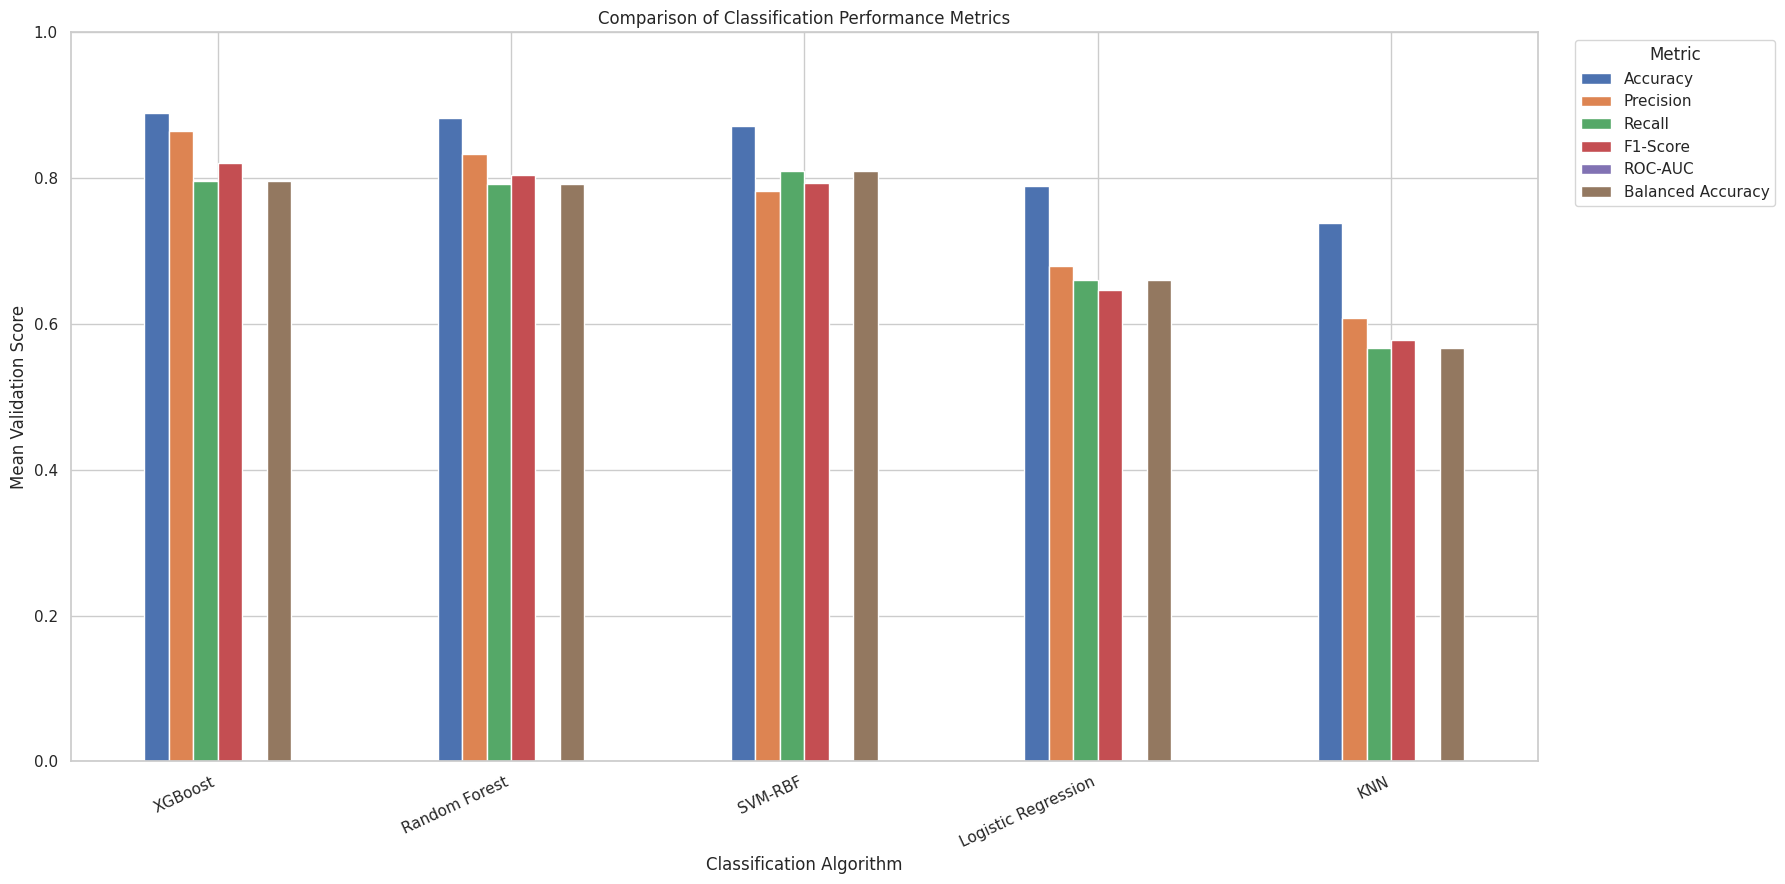

In [24]:
print(
    "\nComparison of Classification Performance Metrics"
)

metrics_for_plot = [
    "Mean_Accuracy",
    "Mean_Precision",
    "Mean_Recall",
    "Mean_F1",
    "Mean_ROC_AUC",
    "Mean_Balanced_Accuracy"
]

plot_data = validation_summary[
    metrics_for_plot
].copy()

plot_data.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy"
]

ax = plot_data.plot(
    kind="bar",
    figsize=(18, 9)
)

plt.title(
    "Comparison of Classification Performance Metrics"
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Mean Validation Score")

plt.ylim(
    0,
    min(
        1.05,
        max(
            1.0,
            plot_data.max().max() + 0.05
        )
    )
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

CROSS-VALIDATION DISTRIBUTIONS

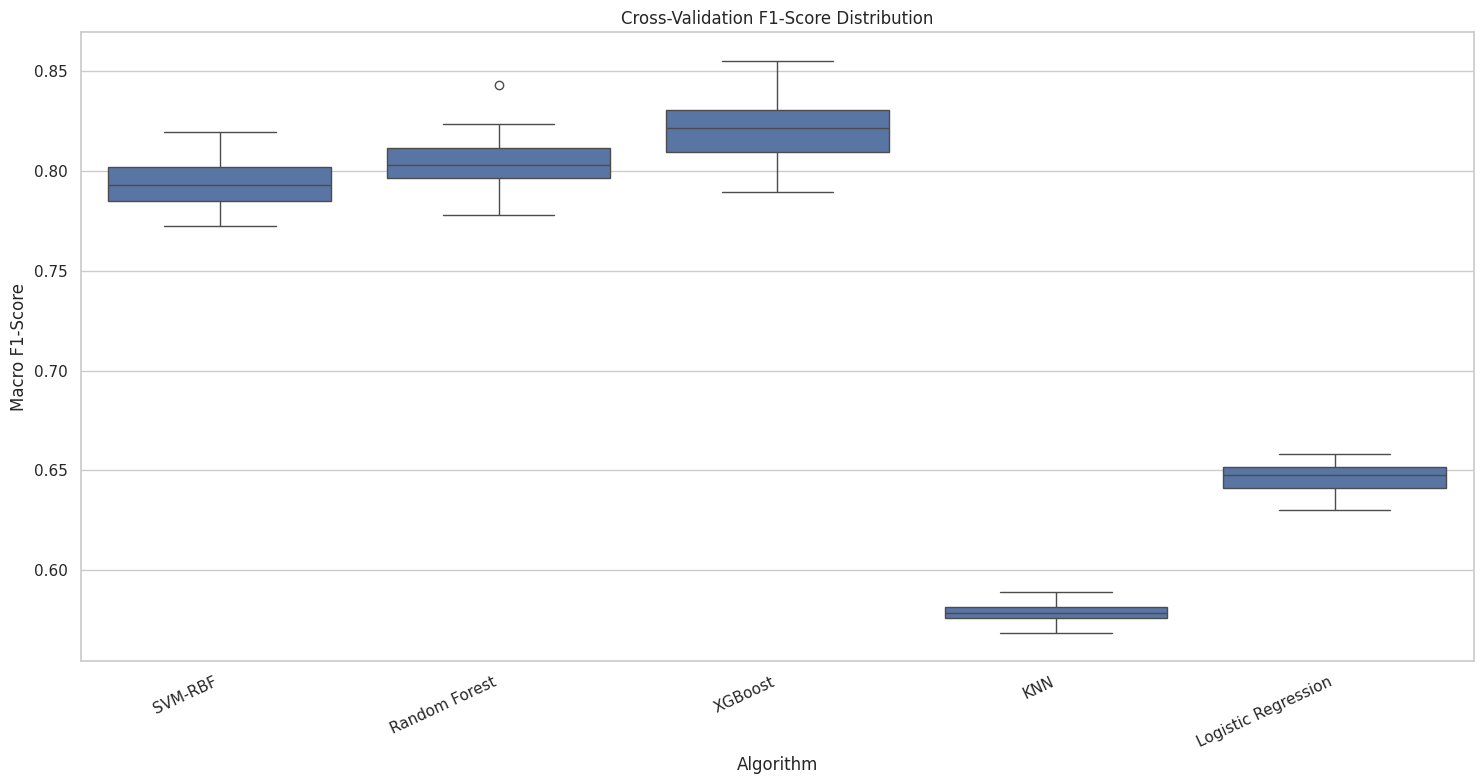

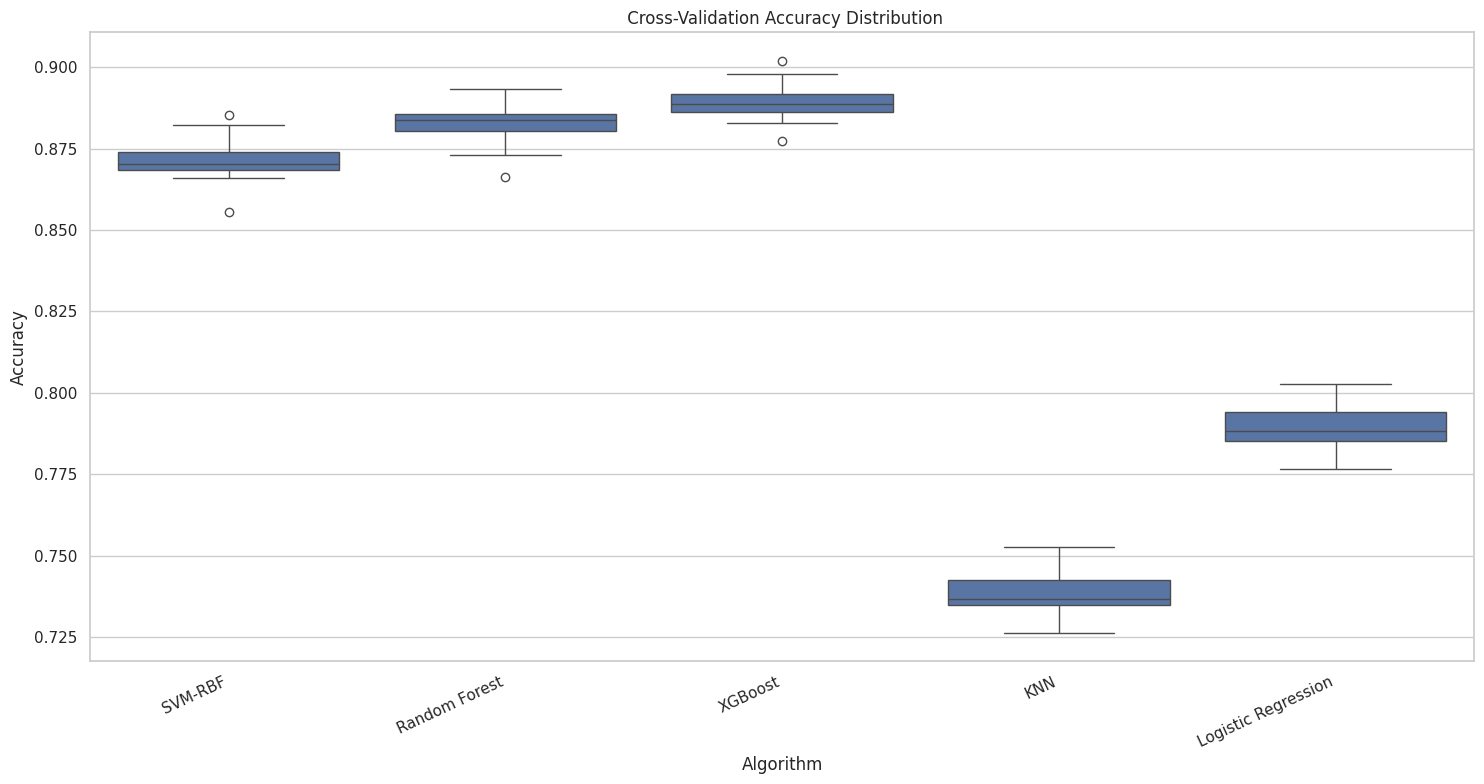

In [25]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=validation_results,
    x="Model",
    y="Macro F1"
)

plt.title(
    "Cross-Validation F1-Score Distribution"
)

plt.xlabel("Algorithm")
plt.ylabel("Macro F1-Score")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 8))

sns.boxplot(
    data=validation_results,
    x="Model",
    y="Accuracy"
)

plt.title(
    " Cross-Validation Accuracy Distribution"
)

plt.xlabel("Algorithm")
plt.ylabel("Accuracy")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

 CLASS-WISE VALIDATION METRICS


Table 7: Class-Wise Performance Comparison


,Model,Class,Precision,Sensitivity,Specificity,F1,ROC_AUC,Support
0,KNN,0,0.8372,0.7003,0.9479,0.7625,0.9551,731.20
1,KNN,1,0.7082,0.8402,0.7575,0.7686,0.8837,1089.75
2,KNN,2,0.8895,0.7991,0.9550,0.8418,0.9199,824.70
3,Logistic Regression,0,0.9079,0.9093,0.9624,0.9086,0.9812,729.60
4,Logistic Regression,1,0.9061,0.8404,0.9338,0.8720,0.9626,1088.25
5,Logistic Regression,2,0.8559,0.9504,0.9381,0.9006,0.9278,702.50
6,Random Forest,0,0.8928,0.9296,0.9567,0.9108,0.9788,730.60
7,Random Forest,1,0.9108,0.8710,0.9391,0.8904,0.9595,1089.20
8,Random Forest,2,0.9201,0.9397,0.9642,0.9297,0.9717,796.60
9,SVM-RBF,0,0.8891,0.9313,0.9547,0.9097,0.9816,728.50


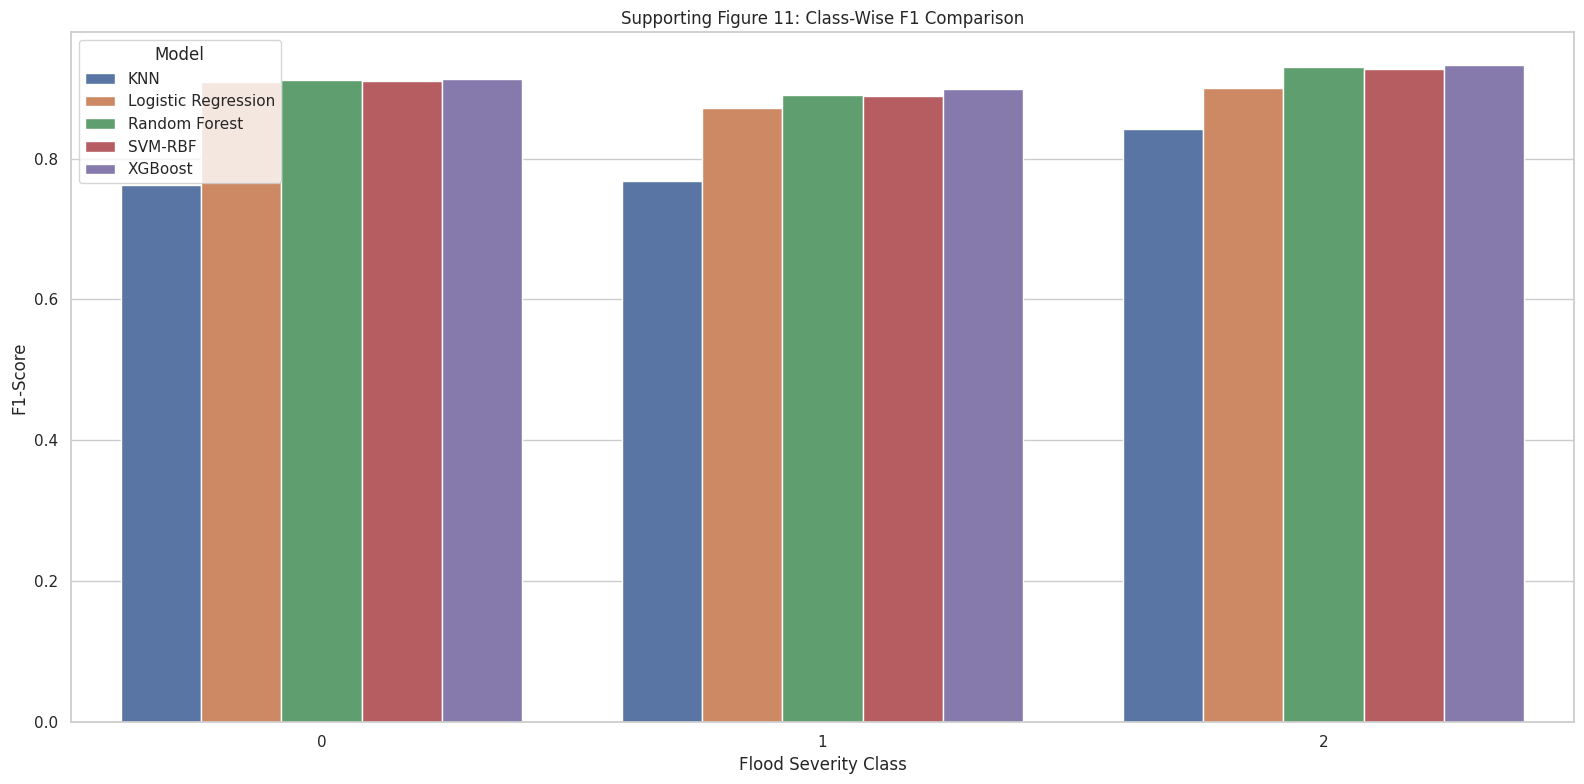

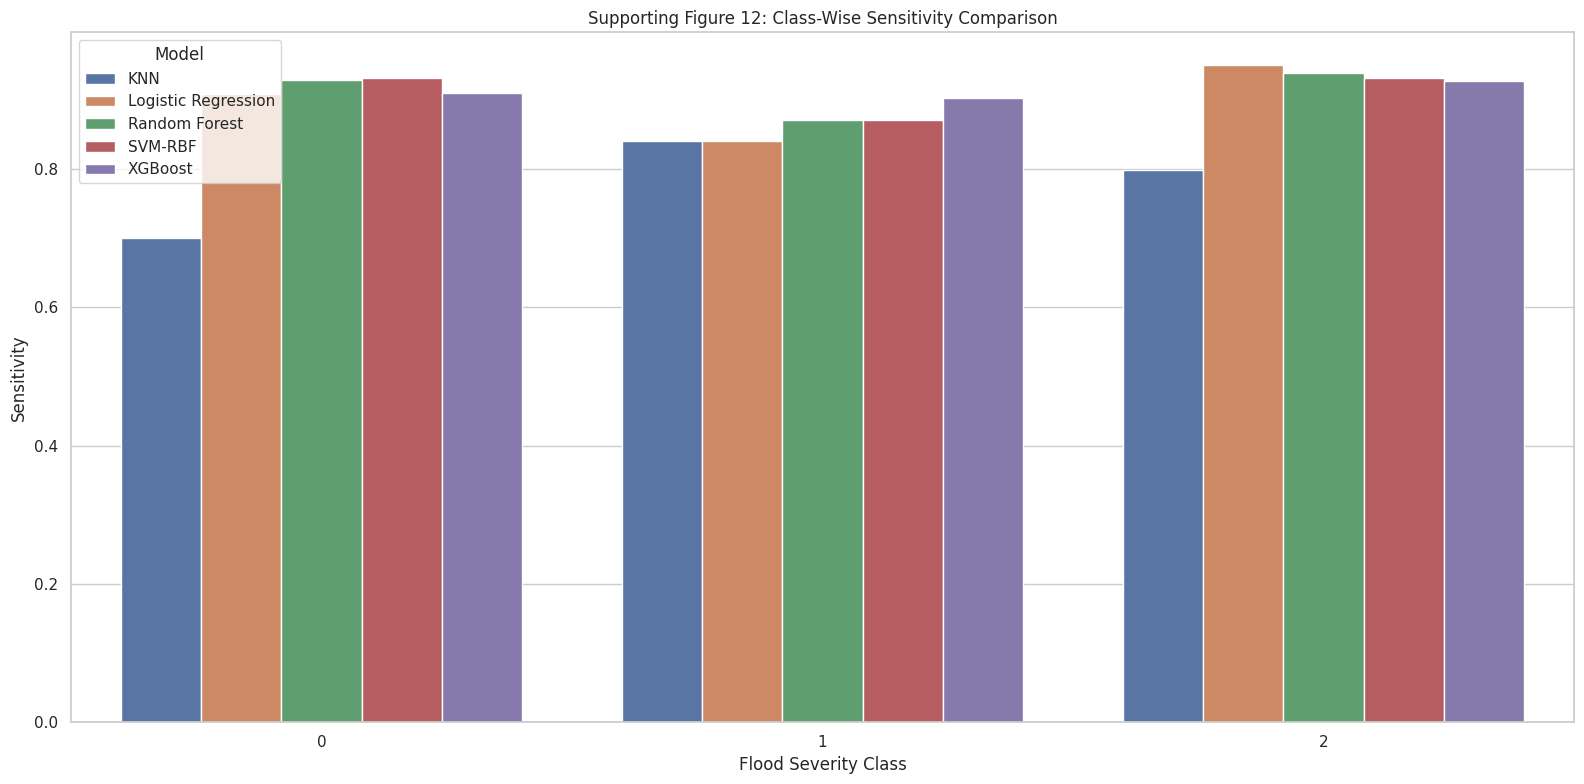

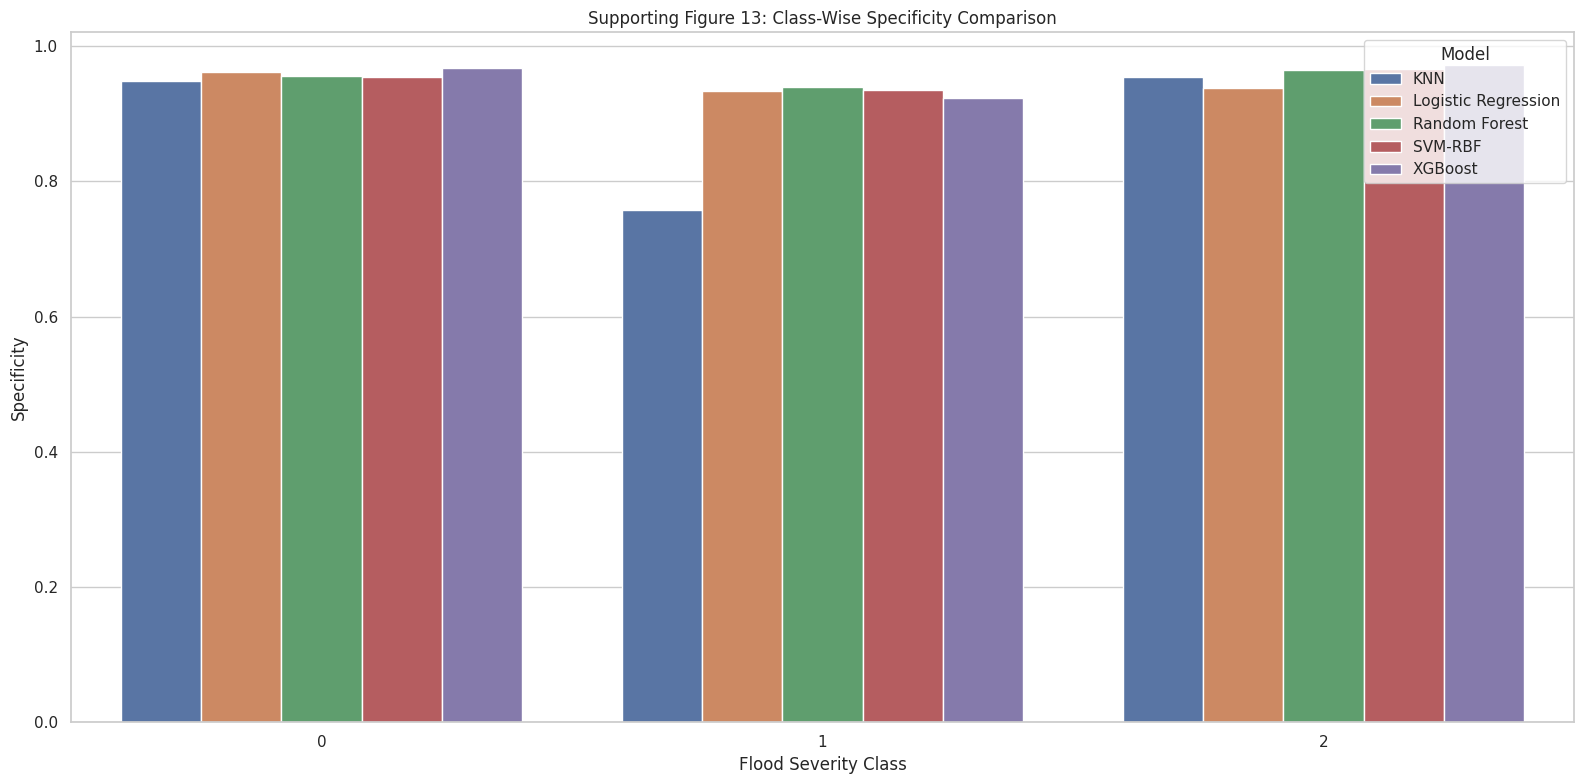

In [26]:
classwise_records = []

for run in range(
    1,
    VALIDATION_RUNS + 1
):

    for model_name in validation_predictions.get(
        run,
        {}
    ):

        data = validation_predictions[
            run
        ][model_name]

        class_metrics = classwise_metrics(
            data["y_true"],
            data["y_pred"],
            data["probability"],
            model_name
        )

        class_metrics["Run"] = run

        classwise_records.append(
            class_metrics
        )

if len(classwise_records) > 0:

    classwise_validation = pd.concat(
        classwise_records,
        ignore_index=True
    )

    classwise_summary = (
        classwise_validation
        .groupby(
            ["Model", "Class"]
        )
        .agg(
            Precision=("Precision", "mean"),
            Sensitivity=("Sensitivity", "mean"),
            Specificity=("Specificity", "mean"),
            F1=("F1-Score", "mean"),
            ROC_AUC=("ROC-AUC", "mean"),
            Support=("Support", "mean")
        )
        .reset_index()
    )

else:

    classwise_summary = pd.DataFrame()


print(
    "\nTable 7: Class-Wise Performance Comparison"
)

display(
    classwise_summary.style.format(
        {
            "Precision": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}",
            "F1": "{:.4f}",
            "ROC_AUC": "{:.4f}",
            "Support": "{:.2f}"
        }
    )
)


# ============================================================
# CLASS-WISE FIGURES
# ============================================================

plt.figure(figsize=(16, 8))

sns.barplot(
    data=classwise_summary,
    x="Class",
    y="F1",
    hue="Model"
)

plt.title(
    "Supporting Figure 11: Class-Wise F1 Comparison"
)

plt.xlabel("Flood Severity Class")
plt.ylabel("F1-Score")

plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 8))

sns.barplot(
    data=classwise_summary,
    x="Class",
    y="Sensitivity",
    hue="Model"
)

plt.title(
    "Supporting Figure 12: Class-Wise Sensitivity Comparison"
)

plt.xlabel("Flood Severity Class")
plt.ylabel("Sensitivity")

plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 8))

sns.barplot(
    data=classwise_summary,
    x="Class",
    y="Specificity",
    hue="Model"
)

plt.title(
    "Supporting Figure 13: Class-Wise Specificity Comparison"
)

plt.xlabel("Flood Severity Class")
plt.ylabel("Specificity")

plt.tight_layout()
plt.show()

MULTICLASS ROC


Receiver Operating Characteristic (ROC) Curve and AUC Comparison


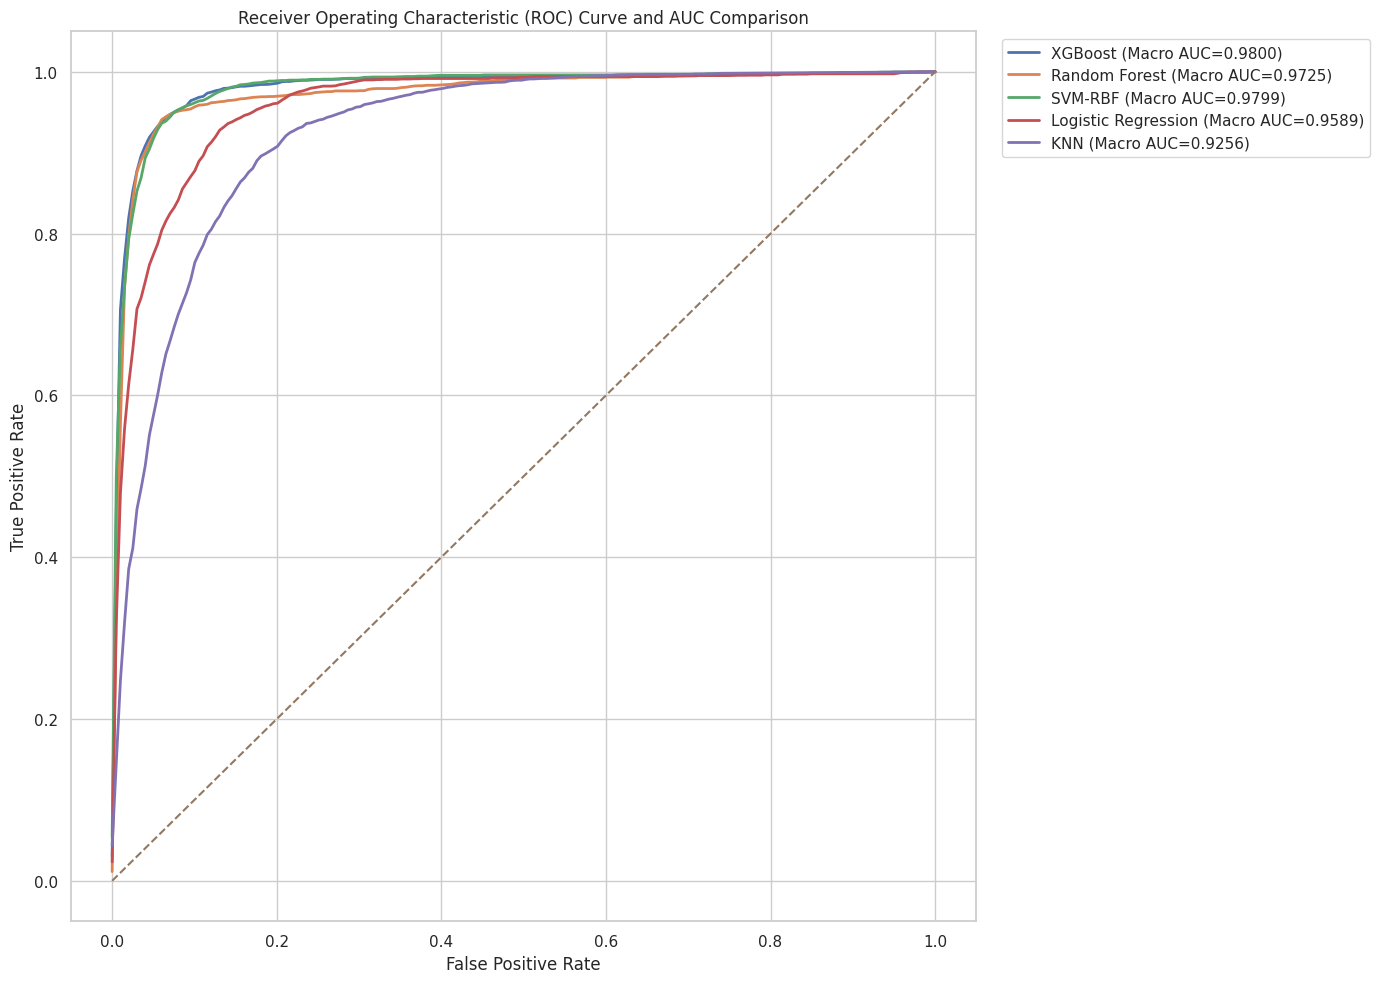

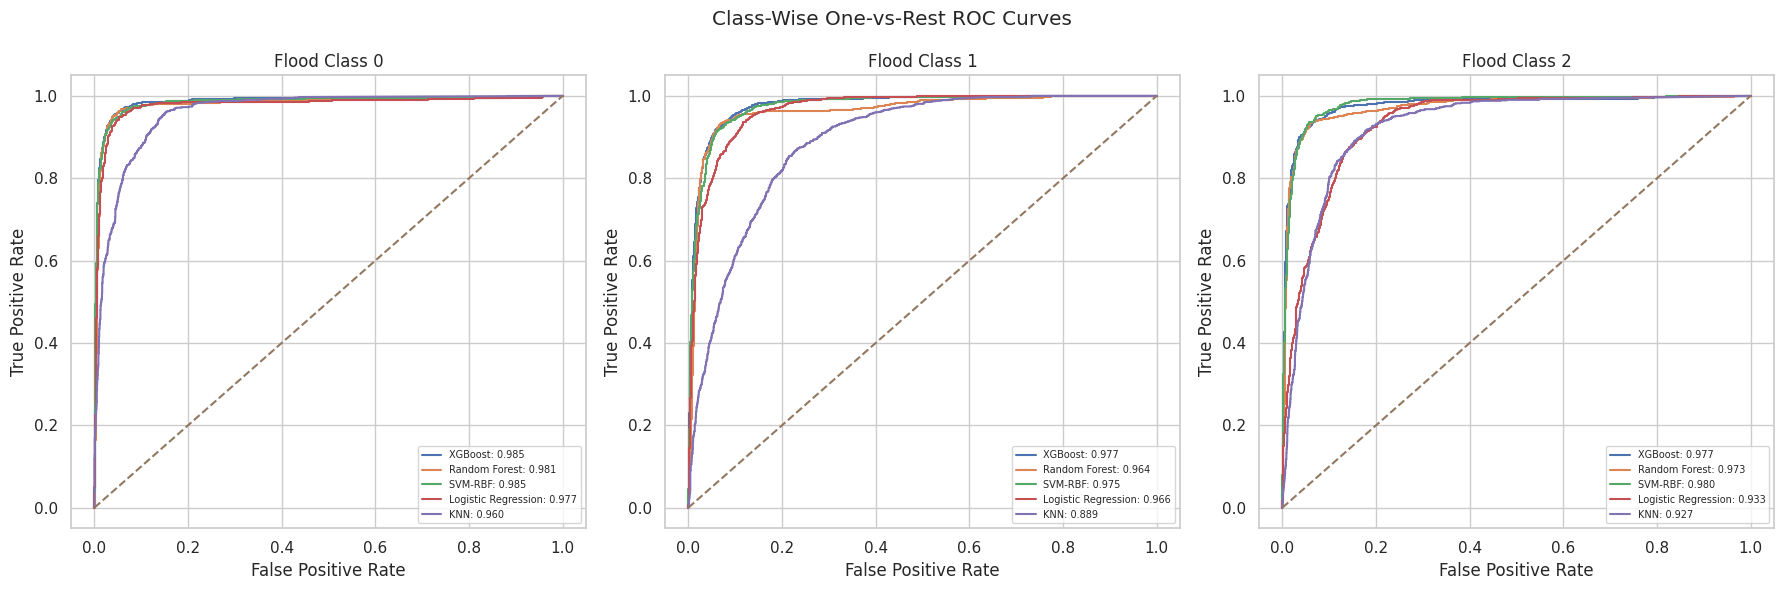

In [27]:
print(
    "\nReceiver Operating Characteristic (ROC) Curve and AUC Comparison"
)

plt.figure(figsize=(14, 10))

for model_name in validation_summary.index:

    model_rows = validation_results[
        validation_results["Model"] == model_name
    ]

    best_run = (
        model_rows
        .sort_values(
            "Macro F1",
            ascending=False
        )
        .iloc[0]["Run"]
    )

    run_data = validation_predictions[
        int(best_run)
    ][model_name]

    y_true_run = run_data["y_true"]
    y_prob_run = run_data["probability"]

    y_binary = label_binarize(
        y_true_run,
        classes=classes
    )

    all_fpr = np.linspace(
        0,
        1,
        200
    )

    mean_tpr = np.zeros_like(
        all_fpr
    )

    class_auc_values = []

    for i, class_label in enumerate(
        classes
    ):

        fpr, tpr, _ = roc_curve(
            y_binary[:, i],
            y_prob_run[:, i]
        )

        class_auc = auc(
            fpr,
            tpr
        )

        class_auc_values.append(
            class_auc
        )

        mean_tpr += np.interp(
            all_fpr,
            fpr,
            tpr
        )

    mean_tpr /= len(classes)

    macro_auc = np.mean(
        class_auc_values
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(Macro AUC={macro_auc:.4f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "Receiver Operating Characteristic (ROC) Curve and AUC Comparison"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ============================================================
# CLASS-SPECIFIC ROC CURVES
# ============================================================

fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(18, 6)
)

for class_index, class_label in enumerate(
    classes
):

    ax = axes[class_index]

    for model_name in validation_summary.index:

        model_rows = validation_results[
            validation_results["Model"] == model_name
        ]

        best_run = int(
            model_rows
            .sort_values(
                "Macro F1",
                ascending=False
            )
            .iloc[0]["Run"]
        )

        data = validation_predictions[
            best_run
        ][model_name]

        binary_true = (
            data["y_true"] ==
            class_label
        ).astype(int)

        fpr, tpr, _ = roc_curve(
            binary_true,
            data["probability"][
                :,
                class_index
            ]
        )

        model_auc = auc(
            fpr,
            tpr
        )

        ax.plot(
            fpr,
            tpr,
            label=f"{model_name}: {model_auc:.3f}"
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_title(
        f"Flood Class {class_label}"
    )

    ax.set_xlabel(
        "False Positive Rate"
    )

    ax.set_ylabel(
        "True Positive Rate"
    )

    ax.legend(
        fontsize=7
    )

plt.suptitle(
    "Class-Wise One-vs-Rest ROC Curves"
)

plt.tight_layout()
plt.show()


PREDICTION OUTPUTS


Comparison of Model Prediction Outputs


,Sample,Actual,XGBoost,Random Forest,SVM-RBF,Logistic Regression,KNN
0,1,1,1,1,1,2,1
1,2,2,2,2,2,2,2
2,3,1,1,1,1,1,1
3,4,1,1,1,1,1,1
4,5,0,0,0,0,0,0
5,6,1,3,3,4,3,3
6,7,1,1,1,1,1,1
7,8,1,1,1,1,1,1
8,9,1,1,1,1,1,1
9,10,0,0,0,0,0,1


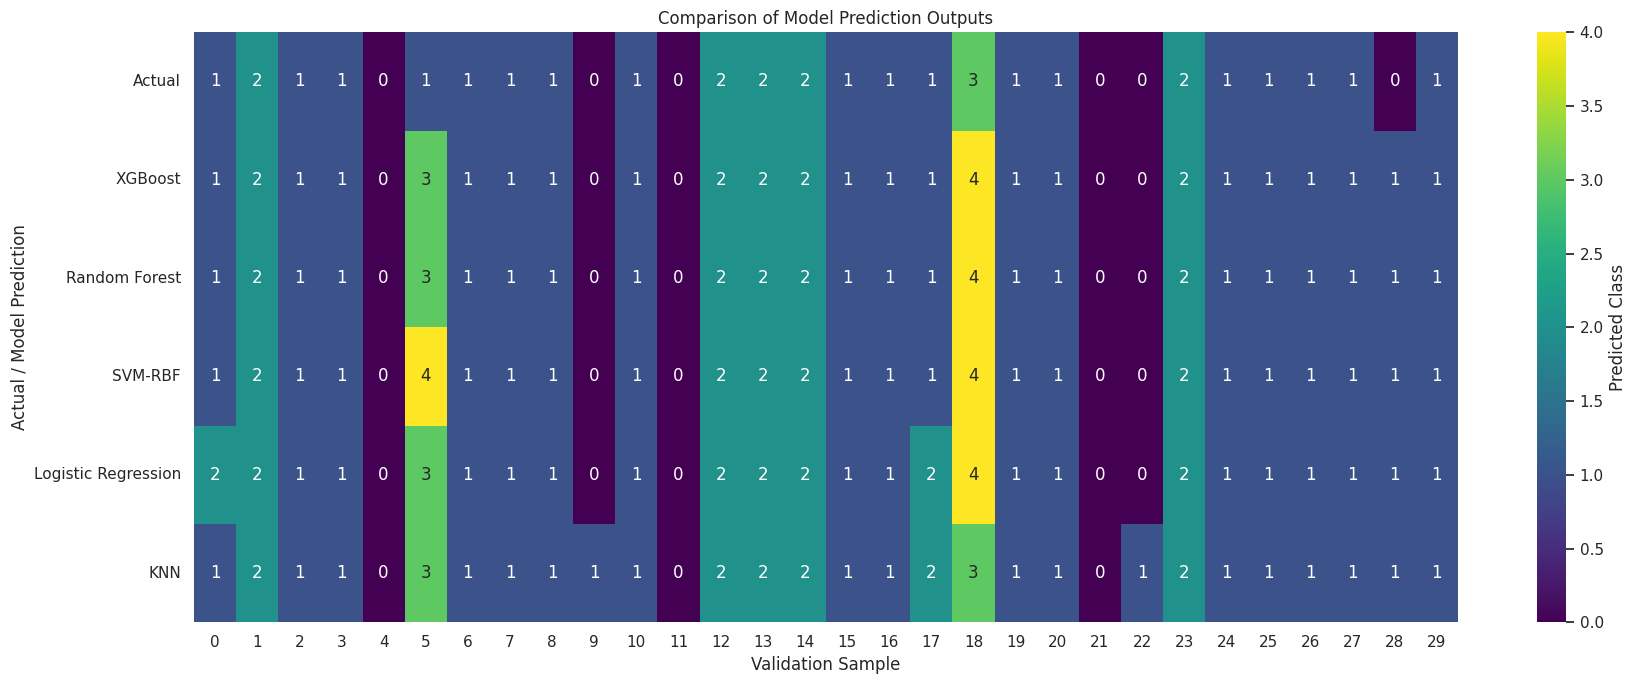

In [28]:
print(
    "\nComparison of Model Prediction Outputs"
)

# Select the first available validation run
prediction_run = 1

run_predictions = validation_predictions[
    prediction_run
]

prediction_length = min(
    30,
    len(
        next(
            iter(
                run_predictions.values()
            )
        )["y_true"]
    )
)

prediction_table = pd.DataFrame({
    "Sample": np.arange(
        1,
        prediction_length + 1
    ),
    "Actual": next(
        iter(
            run_predictions.values()
        )
    )["y_true"][:prediction_length]
})

for model_name in validation_summary.index:

    if model_name in run_predictions:

        prediction_table[
            model_name
        ] = run_predictions[
            model_name
        ]["y_pred"][:prediction_length]


display(prediction_table)

heatmap_data = prediction_table.drop(
    columns=["Sample"]
).T

plt.figure(
    figsize=(18, 7)
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="g",
    cmap="viridis",
    cbar_kws={
        "label": "Predicted Class"
    }
)

plt.title(
    "Comparison of Model Prediction Outputs"
)

plt.xlabel(
    "Validation Sample"
)

plt.ylabel(
    "Actual / Model Prediction"
)

plt.tight_layout()
plt.show()


 MODEL PREDICTION CORRELATION


Correlation Analysis Between Machine Learning Models for One Validation Run
Validation Run Used: 1


,XGBoost,Random Forest,SVM-RBF,Logistic Regression,KNN
XGBoost,1.000000,0.980829,0.966993,0.955952,0.880027
Random Forest,0.980829,1.000000,0.970391,0.958138,0.876604
SVM-RBF,0.966993,0.970391,1.000000,0.947816,0.866341
Logistic Regression,0.955952,0.958138,0.947816,1.000000,0.867865
KNN,0.880027,0.876604,0.866341,0.867865,1.000000


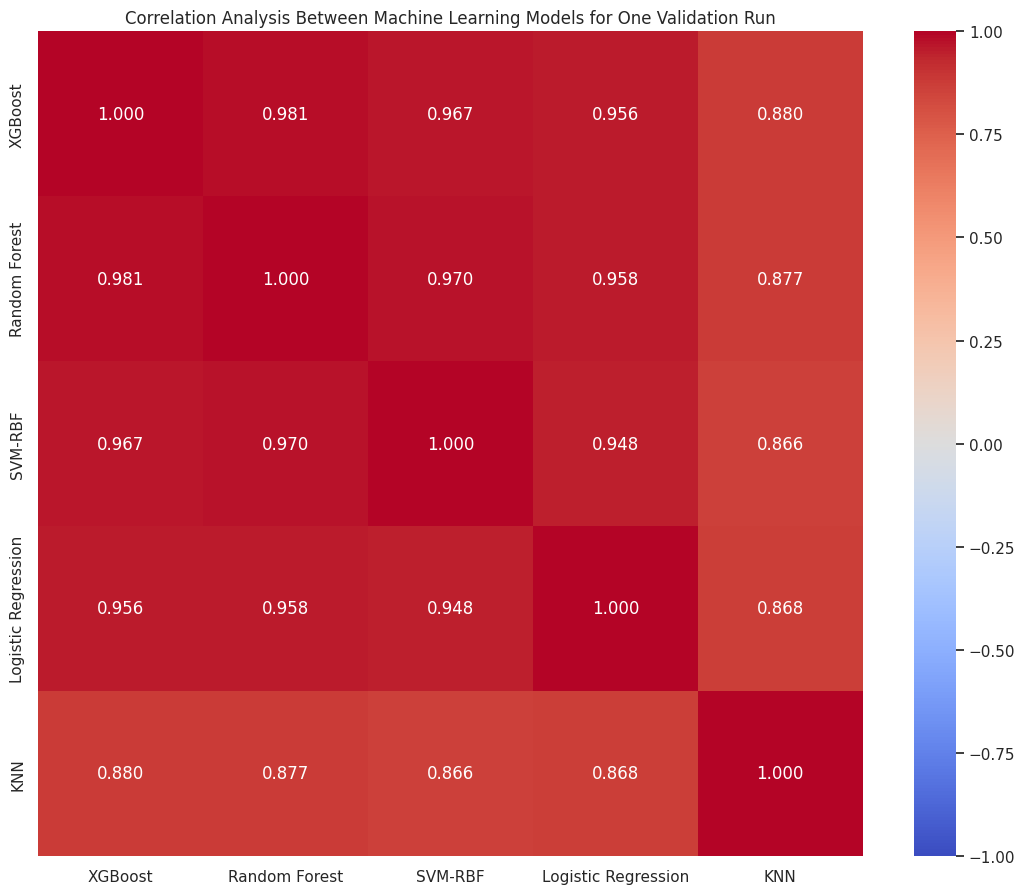

In [29]:
print(
    "\nCorrelation Analysis Between Machine Learning Models for One Validation Run"
)

correlation_prediction_table = pd.DataFrame()

for model_name in validation_summary.index:

    if model_name in validation_predictions[
        prediction_run
    ]:

        correlation_prediction_table[
            model_name
        ] = validation_predictions[
            prediction_run
        ][model_name]["y_pred"]

print(
    "Validation Run Used:",
    prediction_run
)

model_prediction_correlation = (
    correlation_prediction_table
    .corr(
        method="spearman"
    )
)

display(
    model_prediction_correlation
)

plt.figure(
    figsize=(11, 9)
)

sns.heatmap(
    model_prediction_correlation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Correlation Analysis Between Machine Learning Models for One Validation Run"
)

plt.tight_layout()
plt.show()


 STATISTICAL TESTING

In [30]:

print(
    "\n STATISTICAL SIGNIFICANCE COMPARISON"
)

f1_matrix = (
    validation_results
    .pivot(
        index="Run",
        columns="Model",
        values="Macro F1"
    )
)

statistical_records = []

model_names = f1_matrix.columns.tolist()

for model_a, model_b in itertools.combinations(
    model_names,
    2
):

    scores_a = f1_matrix[
        model_a
    ].dropna().values

    scores_b = f1_matrix[
        model_b
    ].dropna().values

    if len(scores_a) == len(scores_b):

        try:

            statistic, p_value = wilcoxon(
                scores_a,
                scores_b,
                zero_method="wilcox",
                alternative="two-sided"
            )

            test_name = "Wilcoxon Signed-Rank"

        except Exception:

            statistic, p_value = ttest_rel(
                scores_a,
                scores_b
            )

            test_name = "Paired t-test"

        statistical_records.append({
            "Model 1": model_a,
            "Model 2": model_b,
            "Test": test_name,
            "Statistic": statistic,
            "p-value": p_value,
            "Significant": (
                "Yes"
                if p_value < ALPHA
                else "No"
            )
        })

statistical_results = pd.DataFrame(
    statistical_records
)

print(
    "\nTable 5: Statistical Significance Comparison of Model Performance"
)

display(
    statistical_results.style.format({
        "Statistic": "{:.4f}",
        "p-value": "{:.6f}"
    })
)




 STATISTICAL SIGNIFICANCE COMPARISON

Table 5: Statistical Significance Comparison of Model Performance


,Model 1,Model 2,Test,Statistic,p-value,Significant
0,KNN,Logistic Regression,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
1,KNN,Random Forest,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
2,KNN,SVM-RBF,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
3,KNN,XGBoost,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
4,Logistic Regression,Random Forest,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
5,Logistic Regression,SVM-RBF,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
6,Logistic Regression,XGBoost,Wilcoxon Signed-Rank,0.0000,0.000002,Yes
7,Random Forest,SVM-RBF,Wilcoxon Signed-Rank,35.0000,0.007296,Yes
8,Random Forest,XGBoost,Wilcoxon Signed-Rank,21.0000,0.000851,Yes
9,SVM-RBF,XGBoost,Wilcoxon Signed-Rank,0.0000,0.000002,Yes


In [31]:
print(
    "\nTable 6: Correlation Analysis Between Model Predictions"
)

display(
    model_prediction_correlation.style.format(
        "{:.4f}"
    )
)



Table 6: Correlation Analysis Between Model Predictions


,XGBoost,Random Forest,SVM-RBF,Logistic Regression,KNN
XGBoost,1.0000,0.9808,0.9670,0.9560,0.8800
Random Forest,0.9808,1.0000,0.9704,0.9581,0.8766
SVM-RBF,0.9670,0.9704,1.0000,0.9478,0.8663
Logistic Regression,0.9560,0.9581,0.9478,1.0000,0.8679
KNN,0.8800,0.8766,0.8663,0.8679,1.0000


IMBALANCED VS BALANCED EVALUATION


 IMBALANCED VS BALANCED DATA EVALUATION

Original Training Distribution:


,Count
flood_severity_stage,
0,3665
1,5453
2,4204
3,1843
4,239



Balanced Training Distribution:


,Count
flood_severity_stage,
0,5453
1,5453
2,5453
3,5453
4,5453


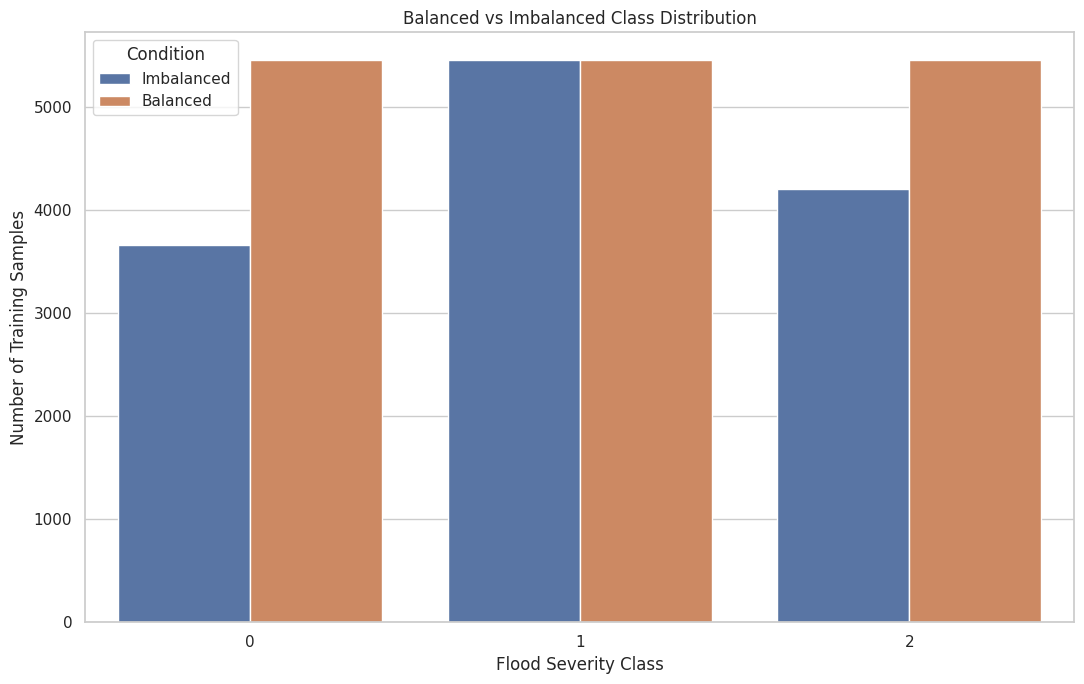


Evaluating Condition: Imbalanced

Evaluating Condition: Balanced

Table 8: Balanced vs Imbalanced Dataset Performance


,Model,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,Balanced Accuracy,Sensitivity,Specificity
0,SVM-RBF,Imbalanced,0.8702,0.8047,0.8244,0.8138,nan,0.8244,0.8244,0.9503
1,Random Forest,Imbalanced,0.8815,0.8489,0.8119,0.8252,nan,0.8119,0.8119,0.9521
2,XGBoost,Imbalanced,0.8835,0.8877,0.8106,0.8376,nan,0.8106,0.8106,0.9515
3,KNN,Imbalanced,0.7250,0.5895,0.5593,0.5680,nan,0.5593,0.5593,0.8812
4,Logistic Regression,Imbalanced,0.8023,0.6943,0.6885,0.6691,nan,0.6885,0.6885,0.9473
5,SVM-RBF,Balanced,0.8755,0.8307,0.8107,0.8196,nan,0.8107,0.8107,0.9496
6,Random Forest,Balanced,0.8805,0.8382,0.7615,0.7761,nan,0.7615,0.7615,0.9537
7,XGBoost,Balanced,0.8830,0.8502,0.8384,0.8439,nan,0.8384,0.8384,0.9511
8,KNN,Balanced,0.6455,0.5588,0.5584,0.5512,nan,0.5584,0.5584,0.8491
9,Logistic Regression,Balanced,0.8133,0.7011,0.7155,0.6840,nan,0.7155,0.7155,0.9486



Performance Metrics on Balanced and Imbalanced Data Using All Implemented Algorithms


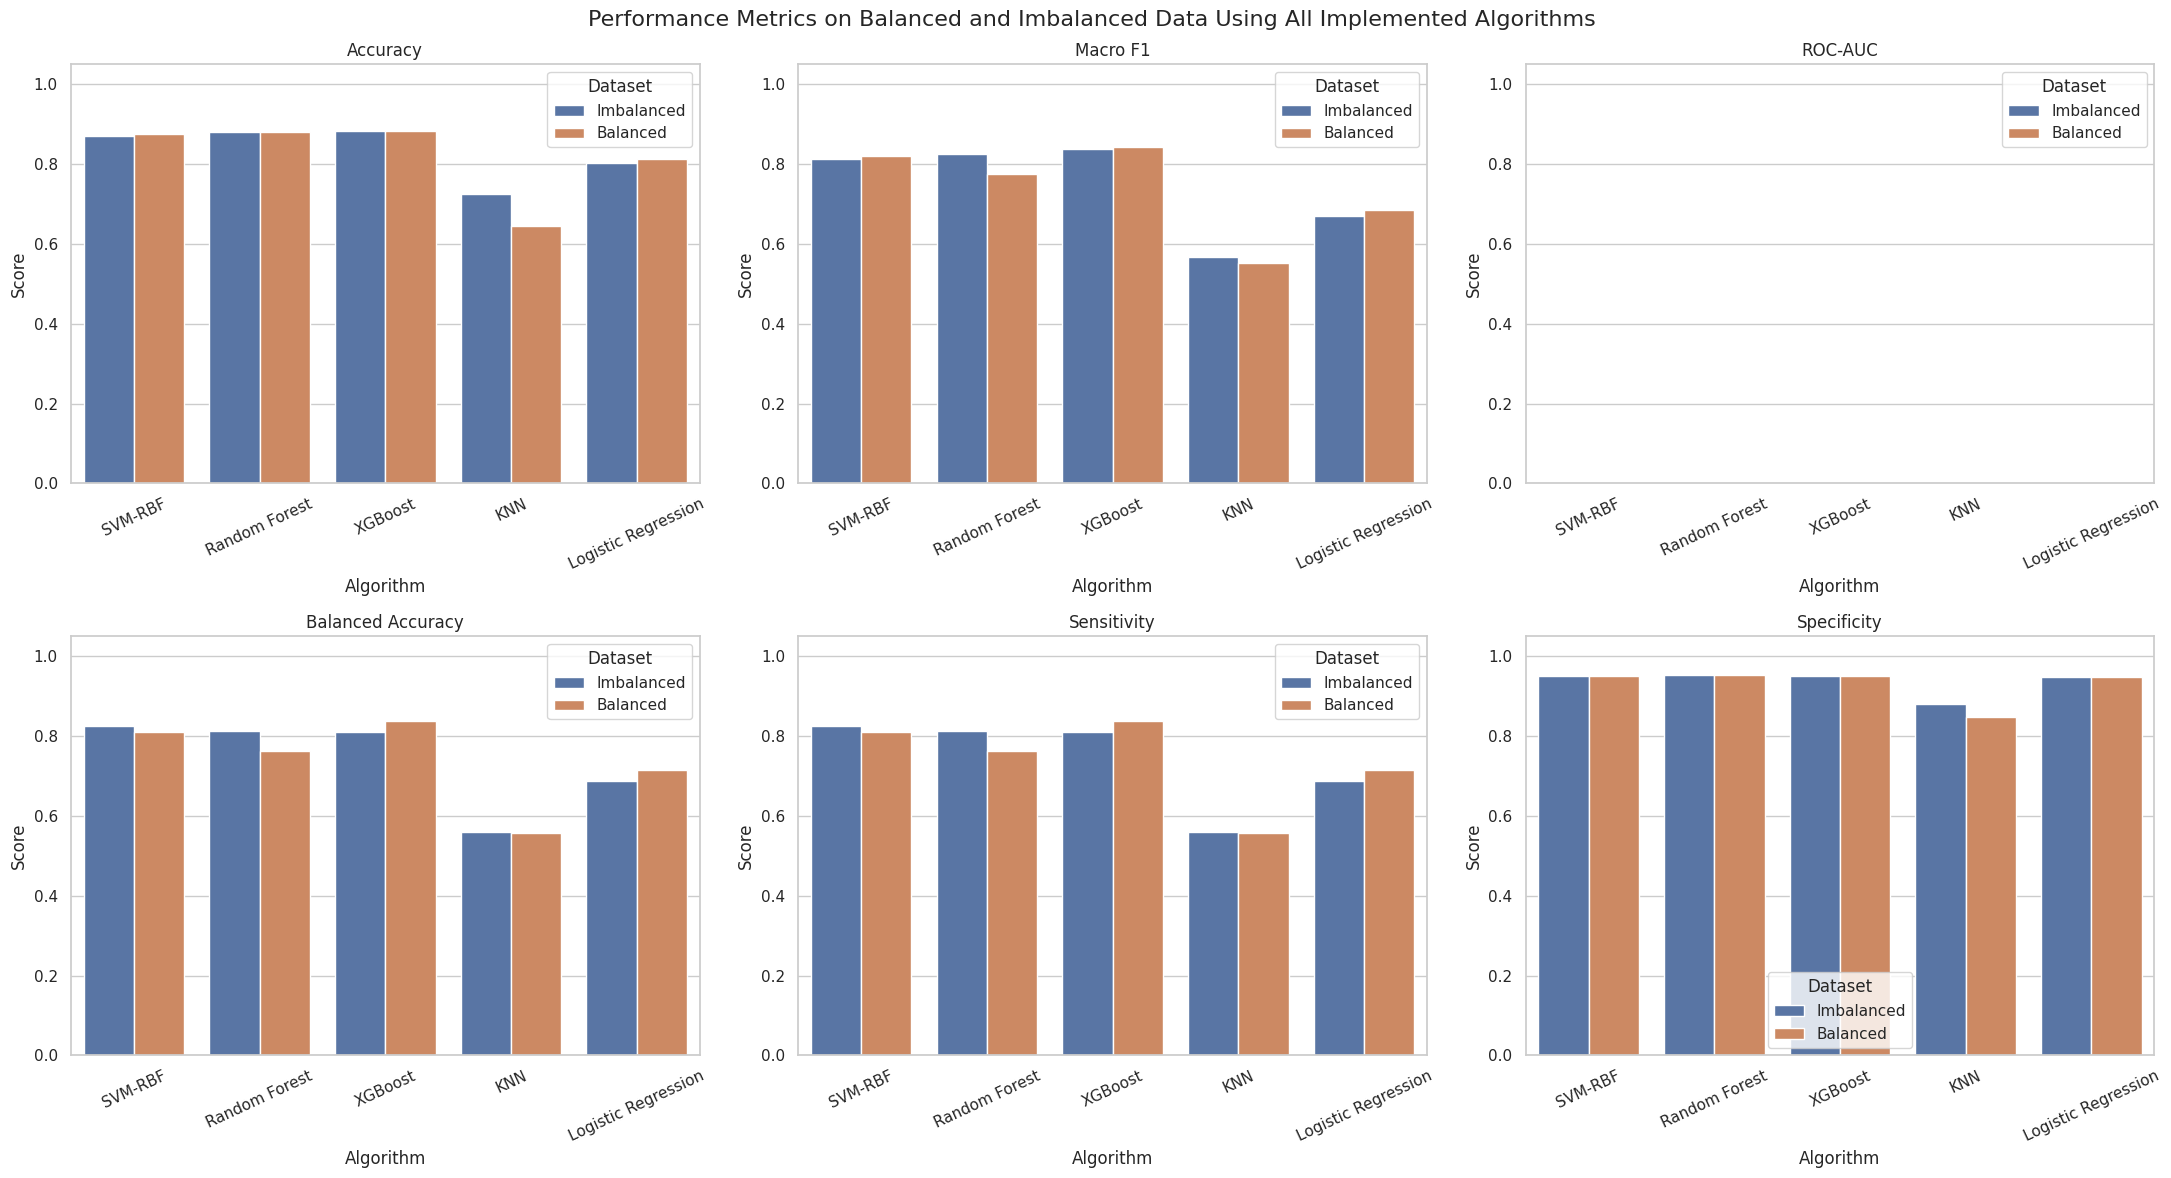


 AUTOMATIC BEST MODEL SELECTION

Model Ranking:


,Rank,Mean_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Mean_ROC_AUC,Mean_Balanced_Accuracy,Mean_Sensitivity,Mean_Specificity,Mean_MCC
Model,,,,,,,,,,
XGBoost,1.0000,0.8891,0.8650,0.7967,0.8202,nan,0.7967,0.7967,0.9546,0.8474
Random Forest,2.0000,0.8828,0.8330,0.7914,0.8046,nan,0.7914,0.7914,0.9533,0.8396
SVM-RBF,3.0000,0.8717,0.7827,0.8096,0.7938,nan,0.8096,0.8096,0.9523,0.8249
Logistic Regression,4.0000,0.7894,0.6801,0.6604,0.6466,nan,0.6604,0.6604,0.9448,0.7213
KNN,5.0000,0.7386,0.6078,0.5669,0.5786,nan,0.5669,0.5669,0.8868,0.6370



Automatically Selected Best Model: XGBoost


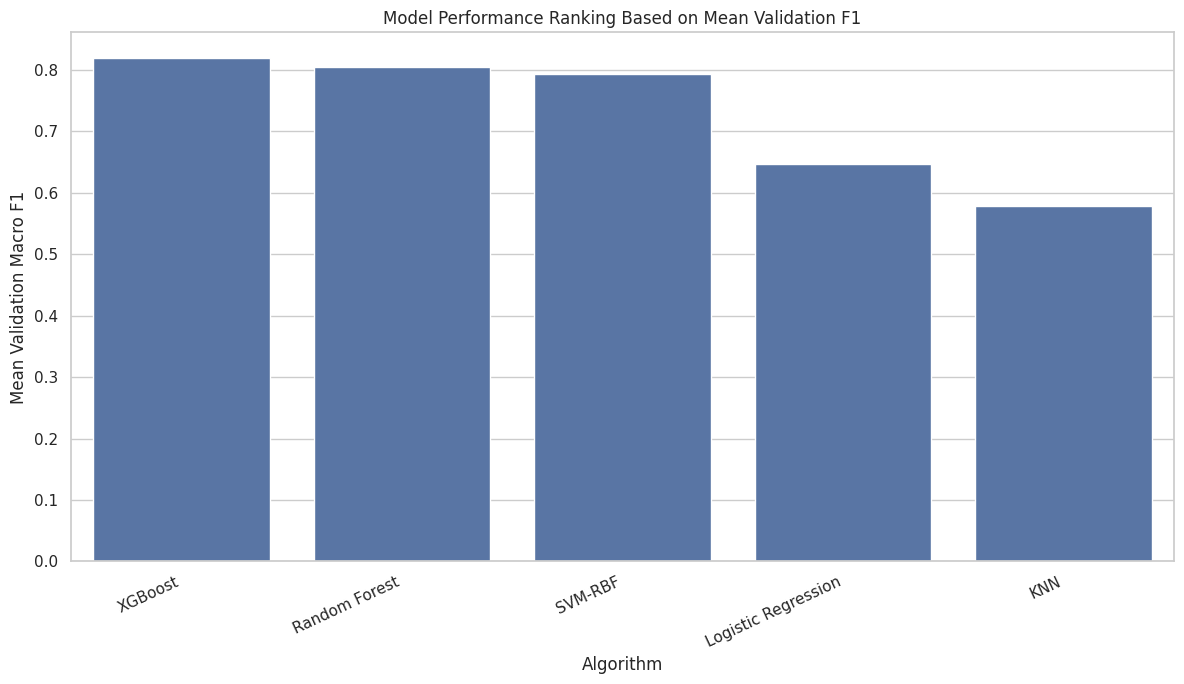

In [32]:
print(
    "\n IMBALANCED VS BALANCED DATA EVALUATION"
)

X_train_original_for_balance = X_train_feature_matrix
y_train_original_for_balance = y_train_clean.reset_index(
    drop=True
)

X_test_for_balance = X_test_feature_matrix

balanced_records = []

# Original training data
balance_conditions = {
    "Imbalanced": (
        X_train_original_for_balance,
        y_train_original_for_balance
    )
}

# SMOTE only on training data
smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_original_for_balance,
    y_train_original_for_balance
)

balance_conditions["Balanced"] = (
    X_train_smote,
    y_train_smote
)

print("\nOriginal Training Distribution:")
display(
    pd.Series(
        y_train_original_for_balance
    )
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

print("\nBalanced Training Distribution:")
display(
    pd.Series(
        y_train_smote
    )
    .value_counts()
    .sort_index()
    .to_frame("Count")
)


# ============================================================
# BALANCED DISTRIBUTION FIGURE
# ============================================================

balance_distribution = pd.DataFrame({
    "Condition": (
        ["Imbalanced"] * len(classes) +
        ["Balanced"] * len(classes)
    ),
    "Class": list(classes) * 2,
    "Count": [
        np.sum(
            y_train_original_for_balance ==
            c
        )
        for c in classes
    ] + [
        np.sum(
            y_train_smote ==
            c
        )
        for c in classes
    ]
})

plt.figure(figsize=(11, 7))

sns.barplot(
    data=balance_distribution,
    x="Class",
    y="Count",
    hue="Condition"
)

plt.title(
    "Balanced vs Imbalanced Class Distribution"
)

plt.xlabel("Flood Severity Class")
plt.ylabel("Number of Training Samples")

plt.tight_layout()
plt.show()


# ============================================================
# BALANCED / IMBALANCED MODEL TRAINING
# ============================================================

for condition_name, (
    X_fit_original,
    y_fit
) in balance_conditions.items():

    print(
        f"\nEvaluating Condition: {condition_name}"
    )

    for model_name, base_model in all_models.items():

        model = base_model

        X_fit = get_model_input(
            model_name,
            X_fit_original,
            None
        )

        X_test_input = get_model_input(
            model_name,
            X_test_for_balance,
            X_test_pca
        )

        # PCA must be fitted separately on the training condition
        # for balanced data to avoid applying a transformation
        # learned from a different distribution.
        if model_name in scaled_models:

            condition_scaler = StandardScaler()

            X_fit_scaled = condition_scaler.fit_transform(
                X_fit_original
            )

            X_test_scaled_condition = (
                condition_scaler.transform(
                    X_test_for_balance
                )
            )

            condition_pca = PCA(
                n_components=min(
                    pca_components,
                    X_fit_scaled.shape[1]
                )
            )

            X_fit = condition_pca.fit_transform(
                X_fit_scaled
            )

            X_test_input = condition_pca.transform(
                X_test_scaled_condition
            )

        else:

            X_fit = X_fit_original
            X_test_input = X_test_for_balance

        model.fit(
            X_fit,
            y_fit
        )

        y_pred = model.predict(
            X_test_input
        )

        y_prob = model.predict_proba(
            X_test_input
        )

        metrics = calculate_metrics(
            y_test,
            y_pred,
            y_prob
        )

        metrics["Dataset"] = condition_name
        metrics["Model"] = model_name

        balanced_records.append(
            metrics
        )


balanced_results = pd.DataFrame(
    balanced_records
)

print(
    "\nTable 8: Balanced vs Imbalanced Dataset Performance"
)

table_8 = balanced_results[
    [
        "Model",
        "Dataset",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "ROC-AUC",
        "Balanced Accuracy",
        "Sensitivity",
        "Specificity"
    ]
]

display(
    table_8.style.format(
        {
            "Accuracy": "{:.4f}",
            "Macro Precision": "{:.4f}",
            "Macro Recall": "{:.4f}",
            "Macro F1": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}"
        }
    )
)


# ============================================================
# FIGURE 9
# ============================================================

print(
    "\nPerformance Metrics on Balanced and Imbalanced Data Using All Implemented Algorithms"
)

balanced_plot_metrics = [
    "Accuracy",
    "Macro F1",
    "ROC-AUC",
    "Balanced Accuracy",
    "Sensitivity",
    "Specificity"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(22, 12)
)

for ax, metric in zip(
    axes.ravel(),
    balanced_plot_metrics
):

    sns.barplot(
        data=balanced_results,
        x="Model",
        y=metric,
        hue="Dataset",
        ax=ax
    )

    ax.set_title(
        metric
    )

    ax.set_xlabel(
        "Algorithm"
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_ylim(
        0,
        1.05
    )

    ax.tick_params(
        axis="x",
        rotation=25
    )

plt.suptitle(
    "Performance Metrics on Balanced and Imbalanced Data Using All Implemented Algorithms",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 27. AUTOMATIC BEST MODEL SELECTION
# ============================================================

print(
    "\n AUTOMATIC BEST MODEL SELECTION"
)

ranking_columns = [
    "Mean_F1",
    "Mean_ROC_AUC",
    "Mean_Balanced_Accuracy",
    "Mean_Accuracy"
]

model_ranking = (
    validation_summary
    .sort_values(
        ranking_columns,
        ascending=False
    )
    .copy()
)

model_ranking[
    "Rank"
] = np.arange(
    1,
    len(model_ranking) + 1
)

print(
    "\nModel Ranking:"
)

display(
    model_ranking[
        [
            "Rank",
            "Mean_Accuracy",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_F1",
            "Mean_ROC_AUC",
            "Mean_Balanced_Accuracy",
            "Mean_Sensitivity",
            "Mean_Specificity",
            "Mean_MCC"
        ]
    ].style.format(
        "{:.4f}"
    )
)

best_model_name = model_ranking.index[0]

print(
    "\nAutomatically Selected Best Model:",
    best_model_name
)


# ============================================================
# SUPPORTING MODEL RANKING FIGURE
# ============================================================

plt.figure(figsize=(12, 7))

ranking_plot = model_ranking.reset_index()

sns.barplot(
    data=ranking_plot,
    x="Model",
    y="Mean_F1"
)

plt.title(
    "Model Performance Ranking Based on Mean Validation F1"
)

plt.xlabel("Algorithm")
plt.ylabel("Mean Validation Macro F1")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

FINAL TRAINING OF ALL MODELS ON TRAINING DATA

In [33]:
print(
    "\n FINAL TRAINING AND TEST-SET EVALUATION"
)

final_models = {}
final_predictions = {}
final_probabilities = {}
final_metrics_records = {}

for model_name, base_model in all_models.items():

    model = base_model

    if model_name in scaled_models:

        model_scaler = StandardScaler()

        X_train_model = model_scaler.fit_transform(
            X_train_feature_matrix
        )

        X_test_model = model_scaler.transform(
            X_test_feature_matrix
        )

        model_pca = PCA(
            n_components=min(
                pca_components,
                X_train_model.shape[1]
            )
        )

        X_train_model = model_pca.fit_transform(
            X_train_model
        )

        X_test_model = model_pca.transform(
            X_test_model
        )

    else:

        X_train_model = X_train_feature_matrix
        X_test_model = X_test_feature_matrix

    model.fit(
        X_train_model,
        y_train_clean
    )

    y_pred = model.predict(
        X_test_model
    )

    y_prob = model.predict_proba(
        X_test_model
    )

    metrics = calculate_metrics(
        y_test,
        y_pred,
        y_prob
    )

    final_models[
        model_name
    ] = {
        "model": model,
        "scaler": (
            model_scaler
            if model_name in scaled_models
            else None
        ),
        "pca": (
            model_pca
            if model_name in scaled_models
            else None
        )
    }

    final_predictions[
        model_name
    ] = y_pred

    final_probabilities[
        model_name
    ] = y_prob

    final_metrics_records[
        model_name
    ] = metrics


final_results = pd.DataFrame(
    final_metrics_records
).T

final_results.index.name = "Model"

final_results = final_results.sort_values(
    [
        "Macro F1",
        "ROC-AUC",
        "Balanced Accuracy",
        "Accuracy"
    ],
    ascending=False
)

print(
    "\nClassification Performance Comparison"
)

display(
    final_results.style.format(
        "{:.4f}"
    )
)


 FINAL TRAINING AND TEST-SET EVALUATION

Classification Performance Comparison


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Balanced Accuracy,MCC,Specificity,Sensitivity,ROC-AUC
Model,,,,,,,,,,,,
XGBoost,0.8835,0.8877,0.8106,0.8376,0.8838,0.8835,0.8824,0.8106,0.8401,0.9515,0.8106,nan
Random Forest,0.8815,0.8489,0.8119,0.8252,0.8811,0.8815,0.8805,0.8119,0.8383,0.9521,0.8119,nan
SVM-RBF,0.8702,0.8047,0.8244,0.8138,0.8718,0.8702,0.8707,0.8244,0.8235,0.9503,0.8244,nan
Logistic Regression,0.8023,0.6943,0.6885,0.6691,0.8505,0.8023,0.8217,0.6885,0.7375,0.9473,0.6885,nan
KNN,0.7250,0.5895,0.5593,0.5680,0.7169,0.7250,0.7147,0.5593,0.6188,0.8812,0.5593,nan


FINAL TEST BEST MODEL

In [34]:
best_test_model = final_results.index[0]

print(
    "\nBest Model Based on Final Test Metrics:",
    best_test_model
)

print(
    "Automatically Selected Validation Model:",
    best_model_name
)


# The final model used for the final prediction is selected
# from validation, not from the test set.
selected_best_model = best_model_name

best_test_prediction = final_predictions[
    selected_best_model
]

best_test_probability = final_probabilities[
    selected_best_model
]


Best Model Based on Final Test Metrics: XGBoost
Automatically Selected Validation Model: XGBoost


 CONFUSION MATRICES FOR ALL MODELS


 CONFUSION MATRICES FOR ALL MODELS


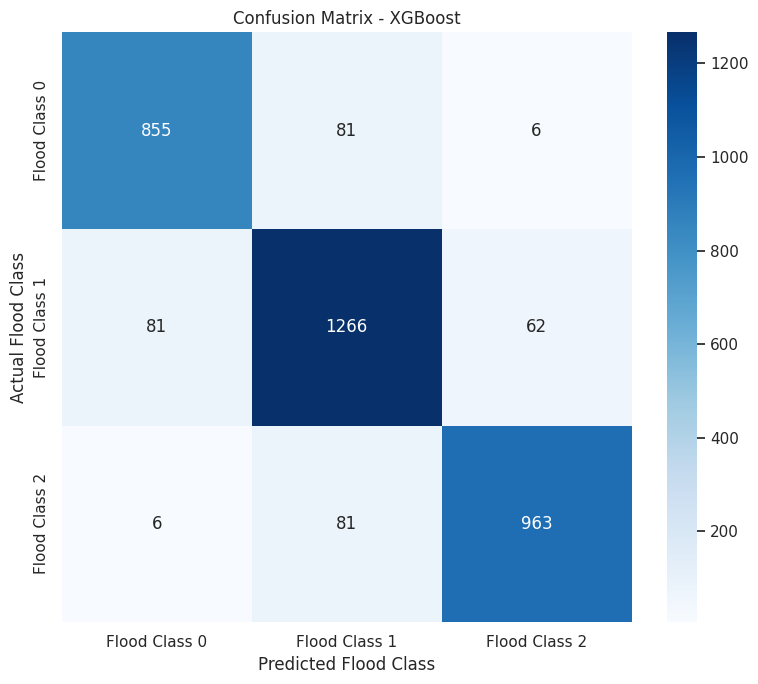

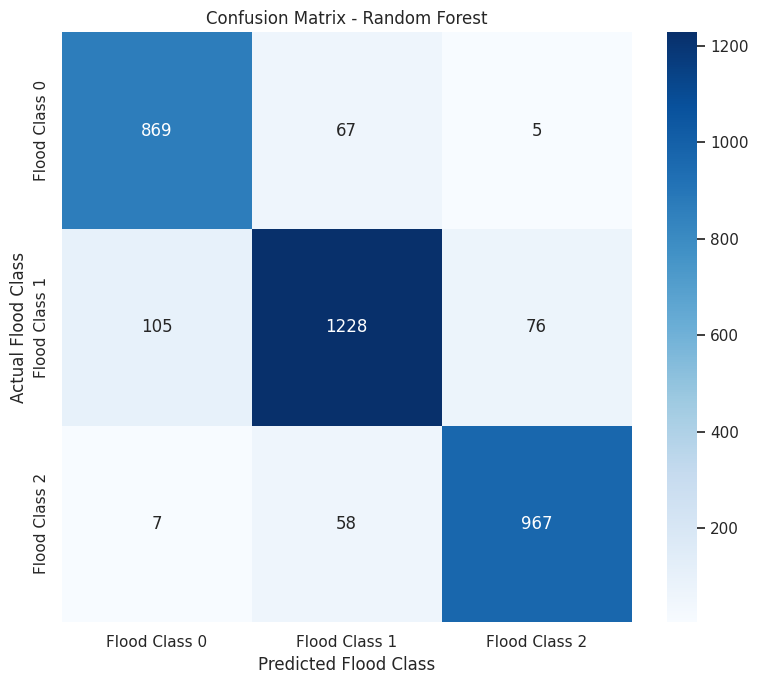

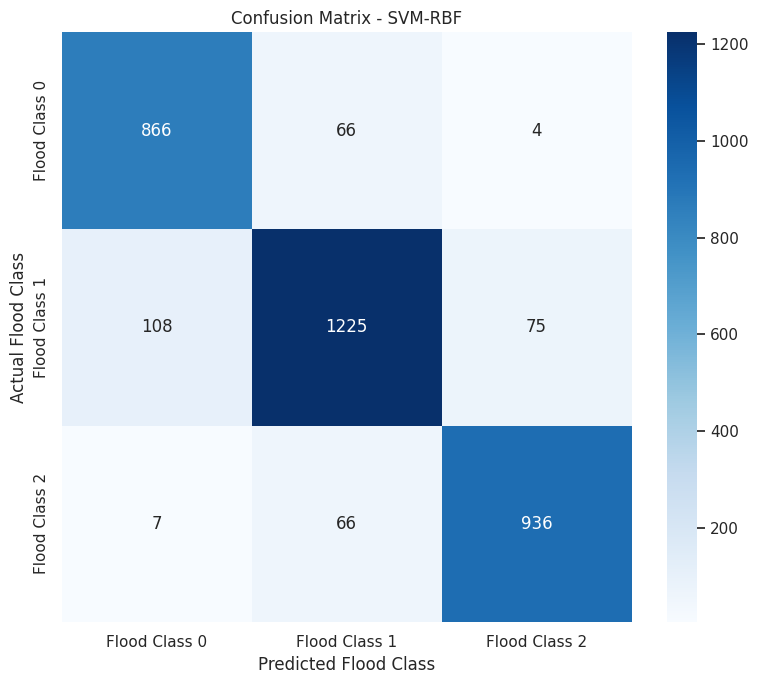

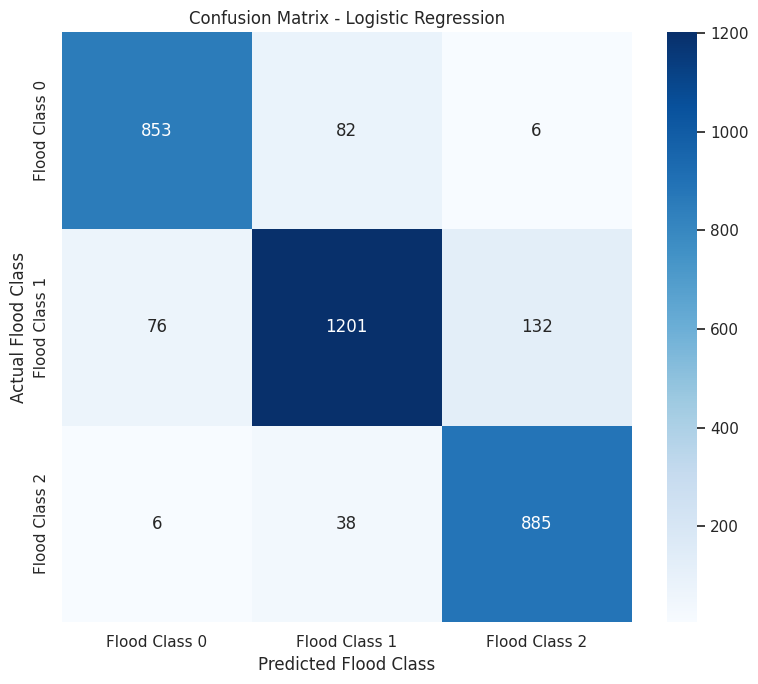

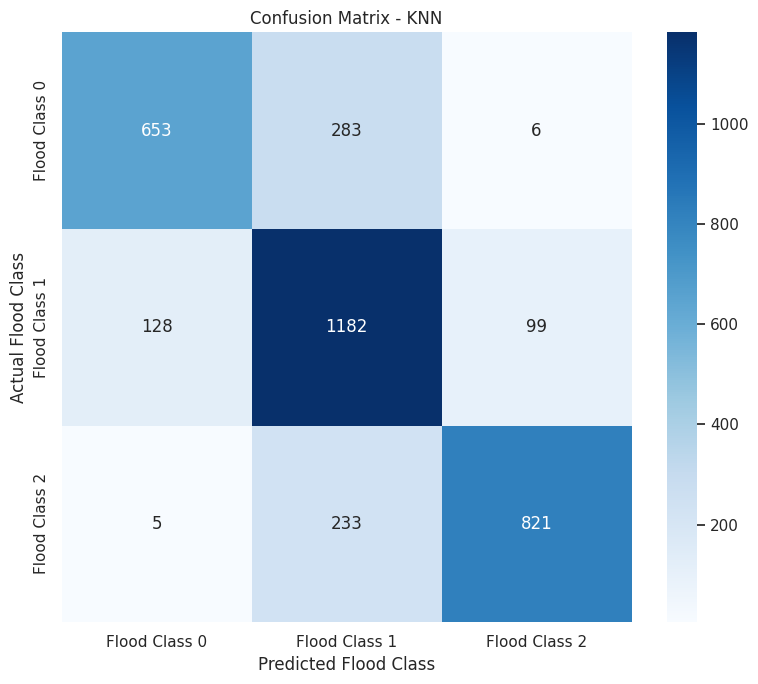

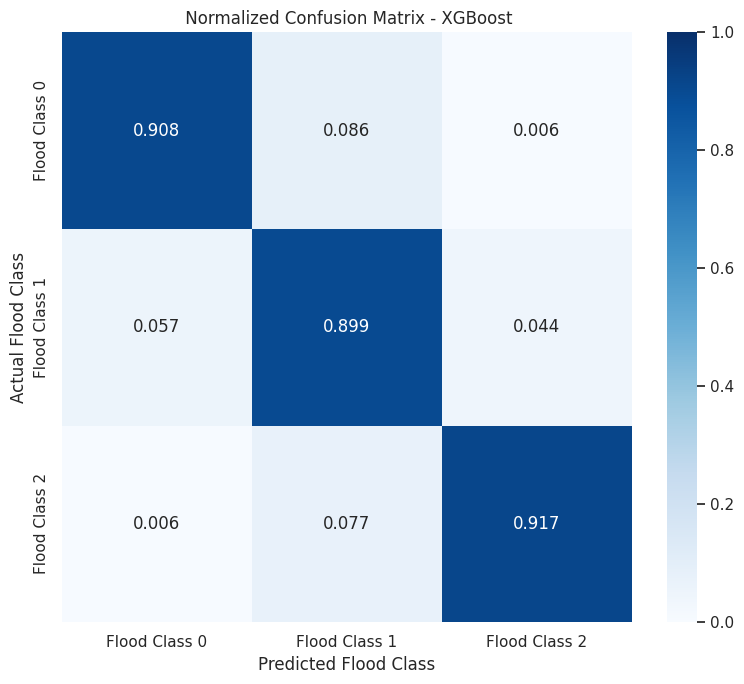

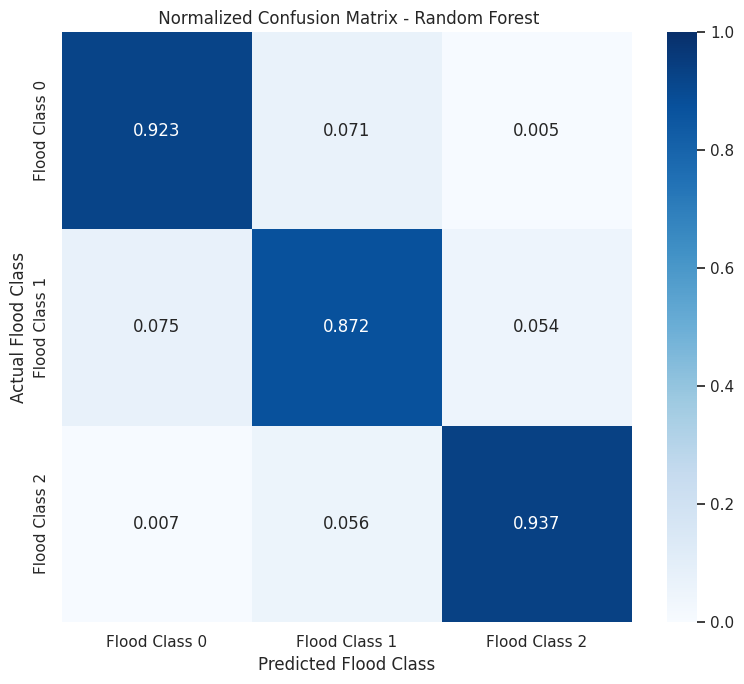

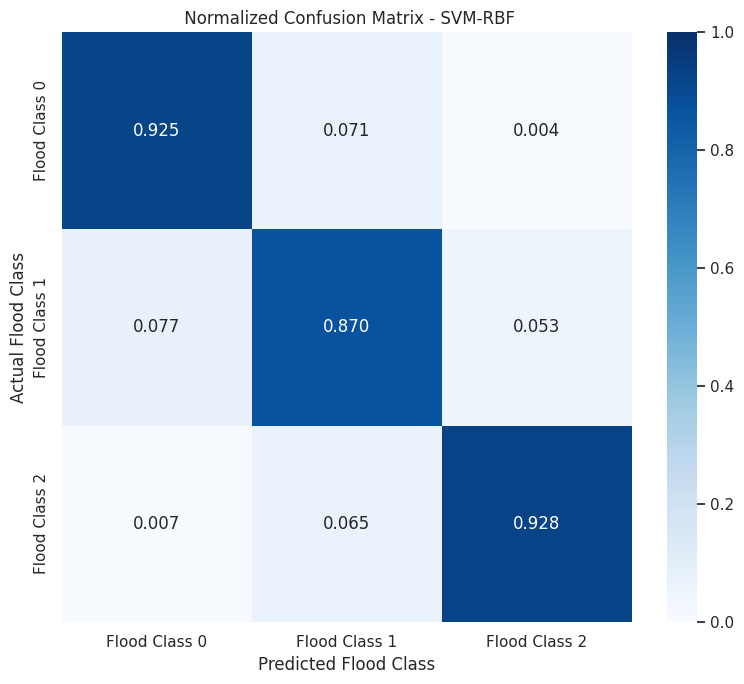

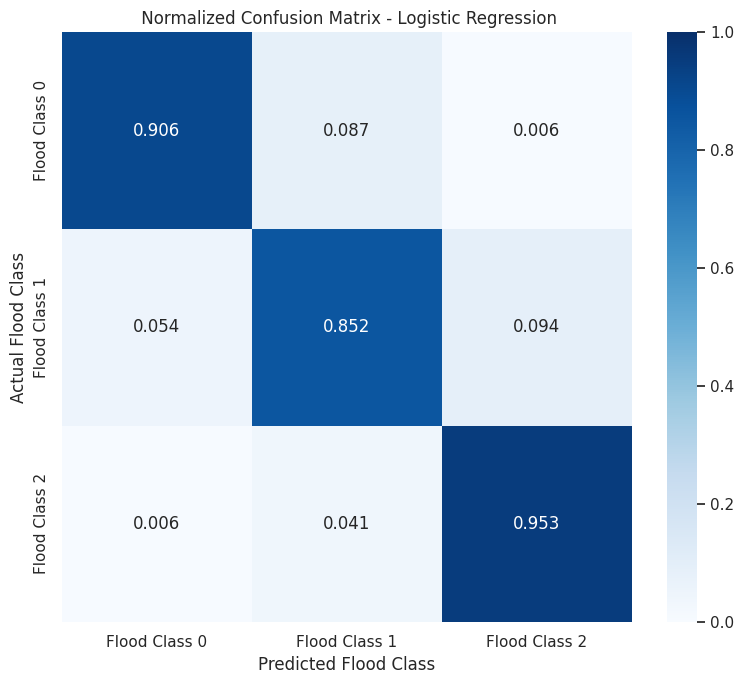

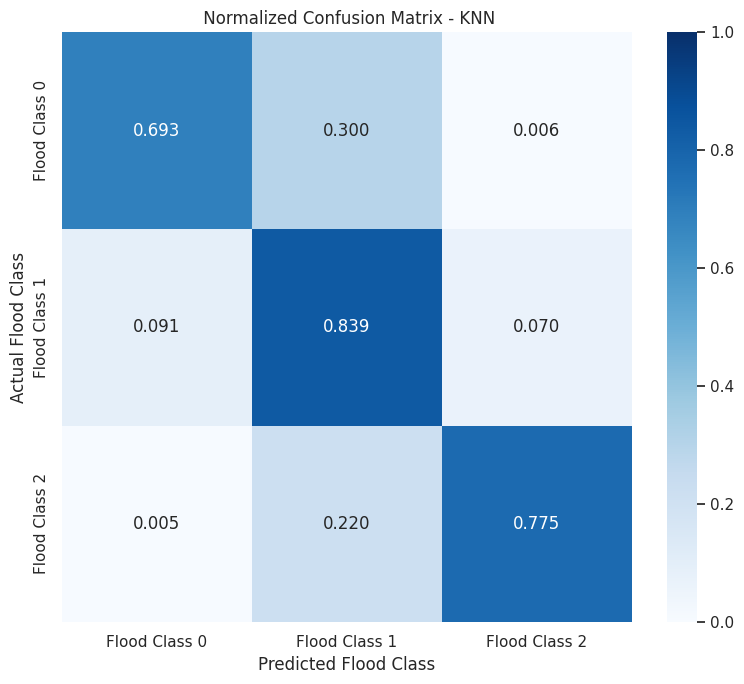

In [35]:

print(
    "\n CONFUSION MATRICES FOR ALL MODELS"
)

for model_name in final_results.index:

    y_pred = final_predictions[
        model_name
    ]

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=classes
    )

    plt.figure(
        figsize=(8, 7)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Flood Class 0",
            "Flood Class 1",
            "Flood Class 2"
        ],
        yticklabels=[
            "Flood Class 0",
            "Flood Class 1",
            "Flood Class 2"
        ]
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel(
        "Predicted Flood Class"
    )

    plt.ylabel(
        "Actual Flood Class"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# NORMALIZED CONFUSION MATRICES
# ============================================================

for model_name in final_results.index:

    y_pred = final_predictions[
        model_name
    ]

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=classes
    )

    cm_normalized = (
        cm.astype(float) /
        np.maximum(
            cm.sum(axis=1, keepdims=True),
            1
        )
    )

    plt.figure(
        figsize=(8, 7)
    )

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        xticklabels=[
            "Flood Class 0",
            "Flood Class 1",
            "Flood Class 2"
        ],
        yticklabels=[
            "Flood Class 0",
            "Flood Class 1",
            "Flood Class 2"
        ],
        vmin=0,
        vmax=1
    )

    plt.title(
        f" Normalized Confusion Matrix - {model_name}"
    )

    plt.xlabel(
        "Predicted Flood Class"
    )

    plt.ylabel(
        "Actual Flood Class"
    )

    plt.tight_layout()
    plt.show()

FINAL CLASS-WISE TEST PERFORMANCE

In [36]:
best_class_test_metrics = classwise_metrics(
    y_test,
    best_test_prediction,
    best_test_probability,
    selected_best_model
)

print(
    "\nFinal Class-Wise Test Performance:"
)

display(
    best_class_test_metrics.style.format(
        {
            "Precision": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}",
            "F1-Score": "{:.4f}",
            "ROC-AUC": "{:.4f}"
        }
    )
)


Final Class-Wise Test Performance:


,Model,Class,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC,Support
0,XGBoost,0,0.9076,0.9076,0.9646,0.9076,0.9808,942
1,XGBoost,1,0.8866,0.8985,0.9187,0.8925,0.9729,1409
2,XGBoost,2,0.9340,0.9171,0.9711,0.9255,0.9765,1050


 FINAL CONFUSION MATRIX

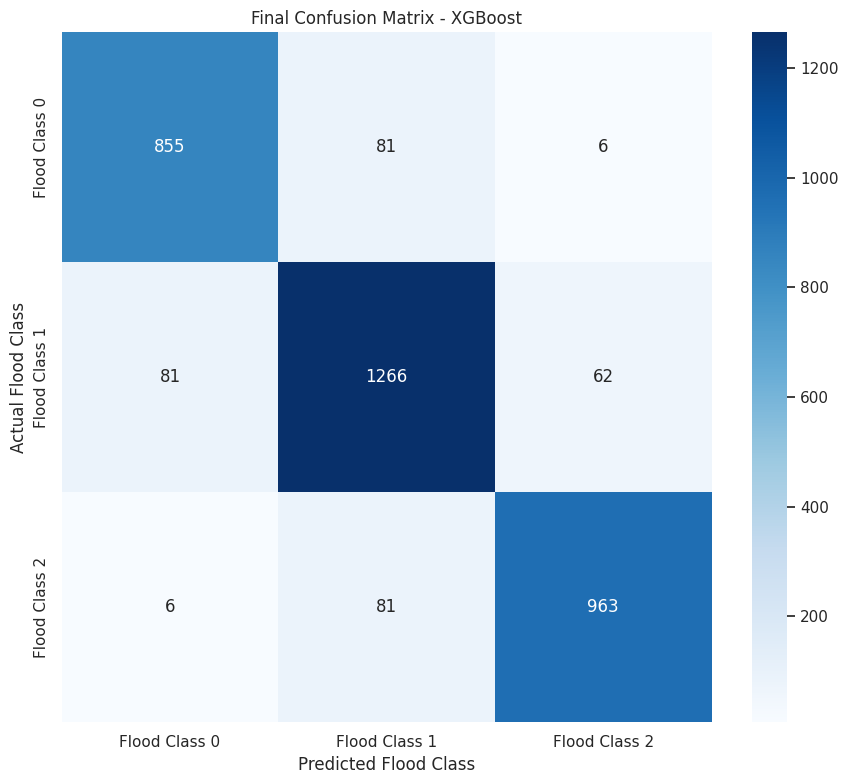

In [37]:
best_cm = confusion_matrix(
    y_test,
    best_test_prediction,
    labels=classes
)

plt.figure(
    figsize=(9, 8)
)

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Flood Class 0",
        "Flood Class 1",
        "Flood Class 2"
    ],
    yticklabels=[
        "Flood Class 0",
        "Flood Class 1",
        "Flood Class 2"
    ]
)

plt.title(
    f"Final Confusion Matrix - {selected_best_model}"
)

plt.xlabel(
    "Predicted Flood Class"
)

plt.ylabel(
    "Actual Flood Class"
)

plt.tight_layout()
plt.show()




 FINAL ROC CURVES FOR BEST MODEL



Final ROC Curves for Automatically Selected Best Model


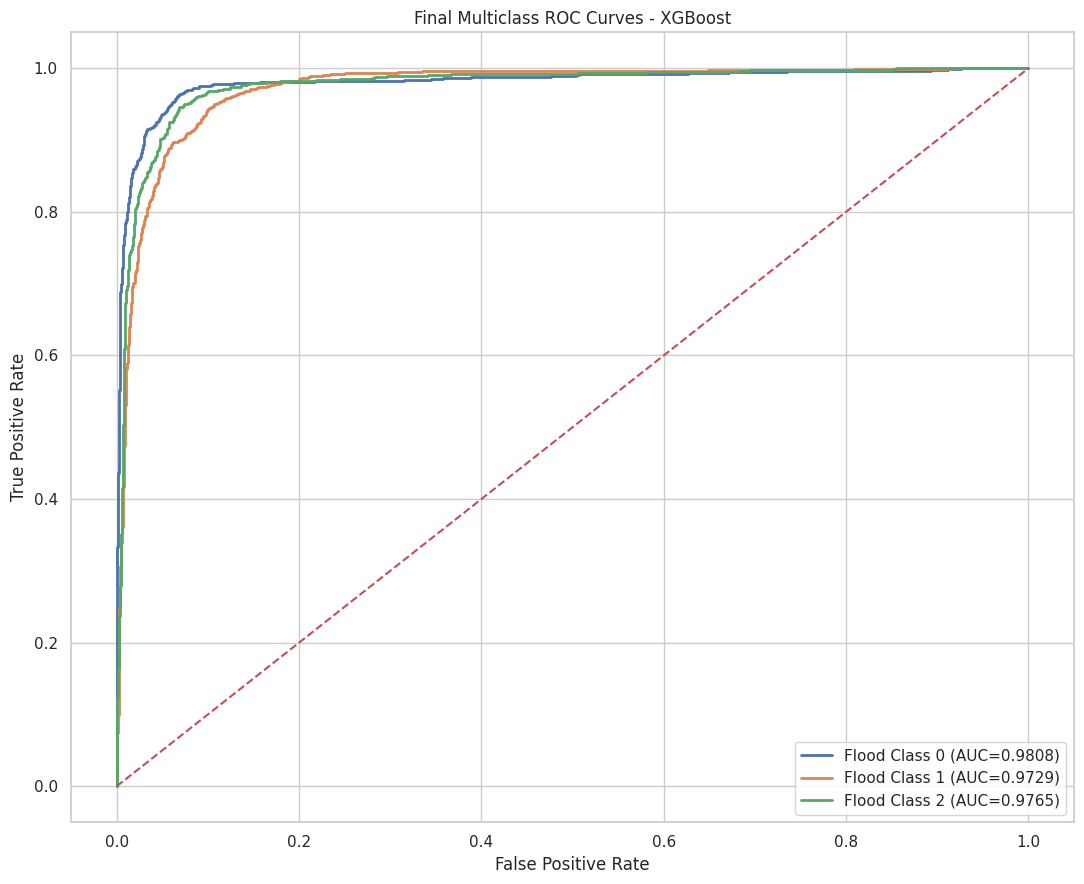


Figure 10: Feature Importance Analysis Using Best Selected Algorithm


,Feature,Importance,Method
0,rainfall_intensity_mmhr,0.836661,Native Feature Importance
1,land_use_code,0.014342,Native Feature Importance
2,land_use_name_Sandy,0.014077,Native Feature Importance
3,drainage_capacity_m3s,0.013373,Native Feature Importance
4,land_use_name_Peat,0.013162,Native Feature Importance
5,temperature_c,0.013120,Native Feature Importance
6,drain_blockage_pct,0.012845,Native Feature Importance
7,impervious_surface_pct,0.012796,Native Feature Importance
8,land_use_name_Rocky,0.012766,Native Feature Importance
9,slope_pct,0.012604,Native Feature Importance


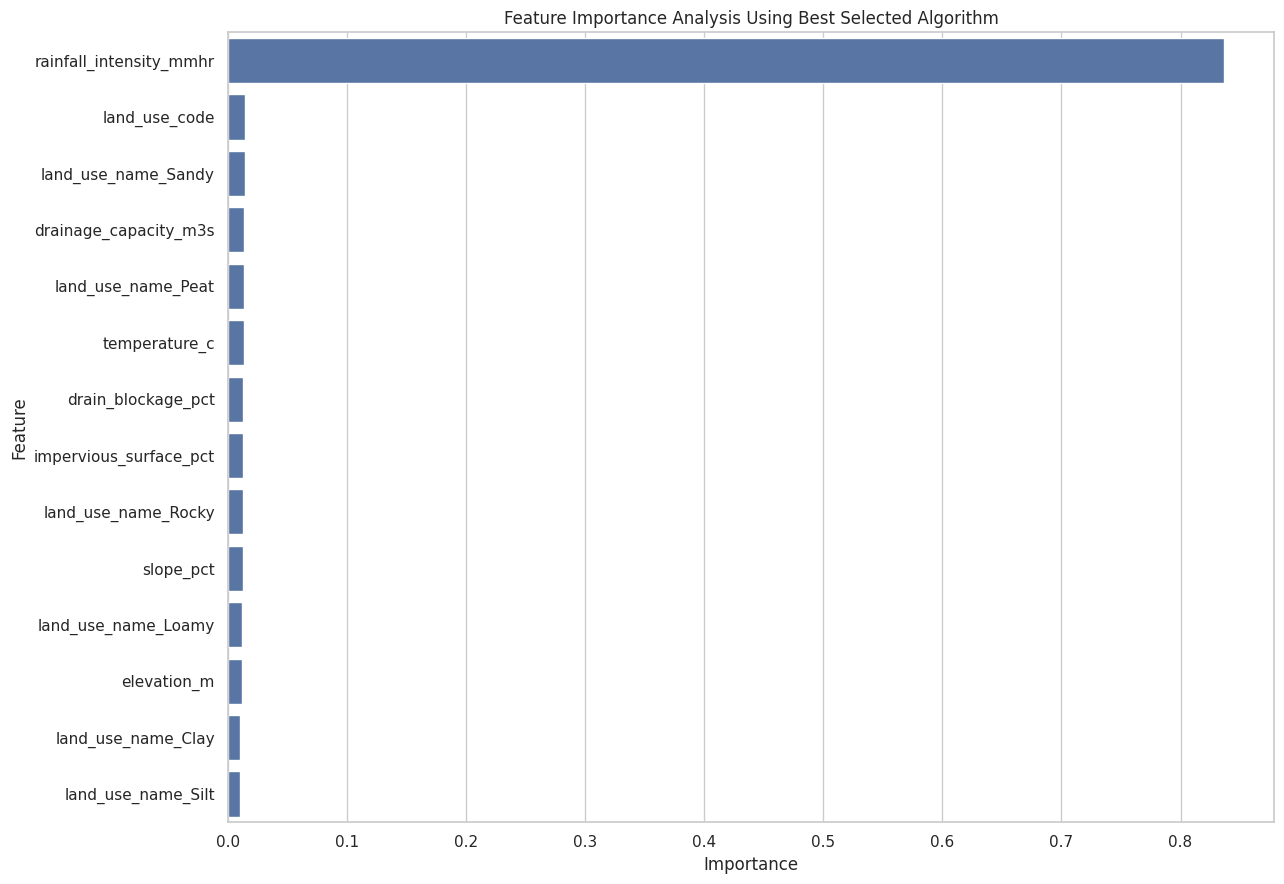

In [38]:
print(
    "\nFinal ROC Curves for Automatically Selected Best Model"
)

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

plt.figure(
    figsize=(11, 9)
)

final_class_auc = {}

for i, class_label in enumerate(
    classes
):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        best_test_probability[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    final_class_auc[
        class_label
    ] = class_auc

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"Flood Class {class_label} "
            f"(AUC={class_auc:.4f})"
        )
    )

macro_auc = np.mean(
    list(
        final_class_auc.values()
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    f"Final Multiclass ROC Curves - {selected_best_model}"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print(
    "\nFigure 10: Feature Importance Analysis Using Best Selected Algorithm"
)

best_model_object = final_models[
    selected_best_model
]["model"]

best_model_scaler = final_models[
    selected_best_model
]["scaler"]

best_model_pca = final_models[
    selected_best_model
]["pca"]


def calculate_original_feature_importance():

    model_name = selected_best_model

    if model_name in [
        "Random Forest",
        "XGBoost",
        "Extra Trees",
        "Gradient Boosting",
        "Hist Gradient Boosting"
    ]:

        if hasattr(
            best_model_object,
            "feature_importances_"
        ):

            importance = (
                best_model_object
                .feature_importances_
            )

            feature_names = (
                all_selected_feature_names
            )

            return pd.DataFrame({
                "Feature": feature_names,
                "Importance": importance,
                "Method": "Native Feature Importance"
            })

    if model_name == "Logistic Regression":

        coefficient_importance = np.mean(
            np.abs(
                best_model_object.coef_
            ),
            axis=0
        )

        if best_model_pca is not None:

            component_importance = (
                coefficient_importance
            )

            loading_matrix = (
                best_model_pca.components_
            )

            scaler_scale = (
                best_model_scaler.scale_
            )

            original_contribution = (
                np.abs(
                    loading_matrix
                ) @
                component_importance
            )

            original_contribution = (
                original_contribution /
                np.maximum(
                    scaler_scale,
                    1e-12
                )
            )

            return pd.DataFrame({
                "Feature": all_selected_feature_names,
                "Importance": original_contribution,
                "Method": (
                    "PCA Loading-Weighted Coefficient Importance"
                )
            })

        else:

            return pd.DataFrame({
                "Feature": all_selected_feature_names,
                "Importance": coefficient_importance,
                "Method": "Absolute Coefficient Magnitude"
            })

    # SVM / KNN / other unsupported native importance
    # use permutation importance on the actual final
    # model input space and map PCA contributions back
    # when PCA is used.

    if model_name in [
        "SVM-RBF",
        "KNN",
        "Gaussian Naive Bayes"
    ]:

        if best_model_pca is not None:

            X_test_transformed = (
                best_model_pca.transform(
                    best_model_scaler.transform(
                        X_test_feature_matrix
                    )
                )
            )

            permutation_result = permutation_importance(
                best_model_object,
                X_test_transformed,
                y_test,
                scoring="f1_macro",
                n_repeats=10,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            component_importance = (
                permutation_result
                .importances_mean
            )

            loading_matrix = (
                best_model_pca.components_
            )

            original_importance = (
                np.abs(
                    loading_matrix
                ).T @
                component_importance
            )

            return pd.DataFrame({
                "Feature": all_selected_feature_names,
                "Importance": original_importance,
                "Method": (
                    "PCA Loading-Weighted Permutation Importance"
                )
            })

        else:

            permutation_result = permutation_importance(
                best_model_object,
                X_test_feature_matrix,
                y_test,
                scoring="f1_macro",
                n_repeats=10,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            return pd.DataFrame({
                "Feature": all_selected_feature_names,
                "Importance": (
                    permutation_result
                    .importances_mean
                ),
                "Method": "Permutation Importance"
            })

    return pd.DataFrame()


feature_importance = (
    calculate_original_feature_importance()
)

if len(feature_importance) > 0:

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    display(
        feature_importance.head(15).style.format(
            {
                "Importance": "{:.6f}"
            }
        )
    )

    top_features = feature_importance.head(
        min(15, len(feature_importance))
    )

    plt.figure(
        figsize=(13, 9)
    )

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature"
    )

    plt.title(
        "Feature Importance Analysis Using Best Selected Algorithm"
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "Feature importance could not be calculated for this model."
    )


FINAL TEST PERFORMANCE

In [39]:
best_metrics = calculate_metrics(
    y_test,
    best_test_prediction,
    best_test_probability
)

table_9 = pd.DataFrame(
    [best_metrics],
    index=[selected_best_model]
)

print(
    "\nTable 9: Final Test-Set Performance of the Automatically Selected Best Model"
)

display(
    table_9.style.format(
        "{:.4f}"
    )
)


Table 9: Final Test-Set Performance of the Automatically Selected Best Model


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Balanced Accuracy,MCC,Specificity,Sensitivity,ROC-AUC
XGBoost,0.8835,0.8877,0.8106,0.8376,0.8838,0.8835,0.8824,0.8106,0.8401,0.9515,0.8106,nan


CLASSIFICATION REPORT

In [40]:
print(
    "\nClassification Report for Automatically Selected Best Model:"
)

print(
    classification_report(
        y_test,
        best_test_prediction,
        labels=classes,
        target_names=[
            "Flood Class 0",
            "Flood Class 1",
            "Flood Class 2"
        ],
        digits=4,
        zero_division=0
    )
)


Classification Report for Automatically Selected Best Model:
               precision    recall  f1-score   support

Flood Class 0     0.9019    0.9048    0.9033       945
Flood Class 1     0.8786    0.8979    0.8881      1410
Flood Class 2     0.8803    0.8851    0.8827      1088

    micro avg     0.8854    0.8957    0.8906      3443
    macro avg     0.8869    0.8959    0.8914      3443
 weighted avg     0.8855    0.8957    0.8906      3443



 ACTUAL VS PREDICTED

In [41]:
final_prediction_output = pd.DataFrame({
    "Sample Index": y_test.index,
    "Actual Flood Class": y_test.values,
    "Predicted Flood Class": best_test_prediction,
    "Prediction Correct": (
        y_test.values ==
        best_test_prediction
    ),
    "Probability Class 0": (
        best_test_probability[:, 0]
    ),
    "Probability Class 1": (
        best_test_probability[:, 1]
    ),
    "Probability Class 2": (
        best_test_probability[:, 2]
    )
})

print(
    "\nFinal Flood Prediction Output:"
)

display(
    final_prediction_output.head(50).style.format(
        {
            "Probability Class 0": "{:.4f}",
            "Probability Class 1": "{:.4f}",
            "Probability Class 2": "{:.4f}"
        }
    )
)



Final Flood Prediction Output:


,Sample Index,Actual Flood Class,Predicted Flood Class,Prediction Correct,Probability Class 0,Probability Class 1,Probability Class 2
0,15774,1,1,True,0.0132,0.9583,0.0153
1,477,1,1,True,0.0126,0.7765,0.1967
2,13467,3,3,True,0.0093,0.0090,0.0126
3,4962,0,0,True,0.9652,0.0076,0.0072
4,13115,3,3,True,0.0083,0.0113,0.0122
5,8803,1,1,True,0.3486,0.6227,0.0137
6,10132,1,1,True,0.0112,0.8733,0.1030
7,12259,3,3,True,0.0101,0.0101,0.0240
8,11366,2,2,True,0.0097,0.0106,0.9669
9,15494,3,3,True,0.0132,0.0146,0.1989


GROUP-WISE PREDICTION ACCURACY


Prediction Accuracy by Flood Severity Group:


,Flood Severity Class,Prediction Accuracy,Samples
0,0,0.9048,945
1,1,0.8979,1410
2,2,0.8851,1088


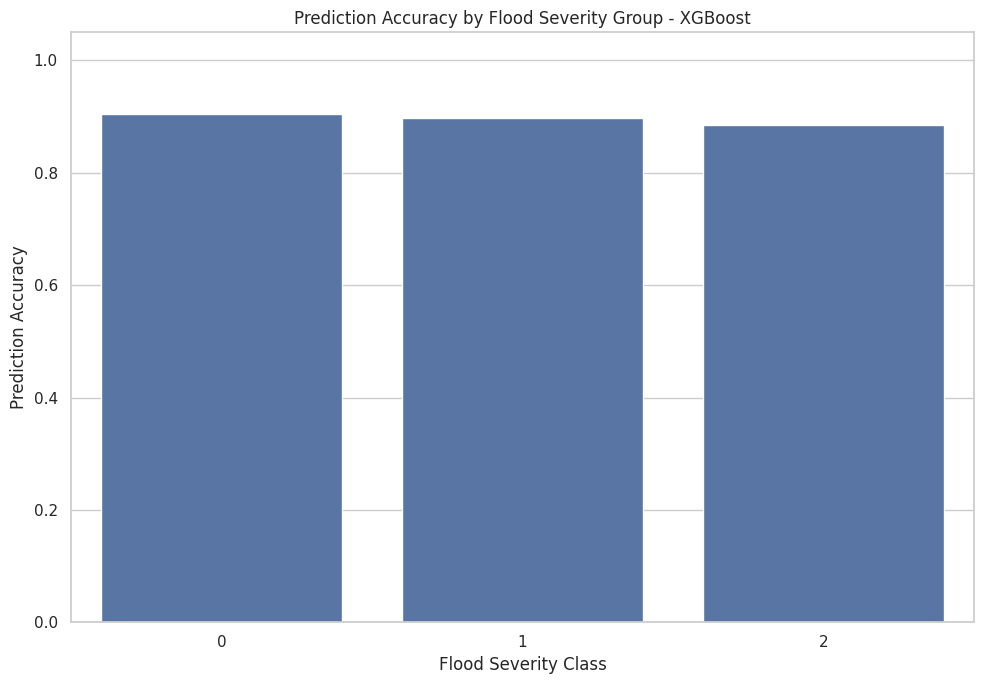


FINAL VALIDATION PERFORMANCE OF ALL IMPLEMENTED ALGORITHMS


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,Sensitivity,Specificity
Model,,,,,,,,
XGBoost,0.8891,0.8650,0.7967,0.8202,nan,0.7967,0.7967,0.9546
Random Forest,0.8828,0.8330,0.7914,0.8046,nan,0.7914,0.7914,0.9533
SVM-RBF,0.8717,0.7827,0.8096,0.7938,nan,0.8096,0.8096,0.9523
Logistic Regression,0.7894,0.6801,0.6604,0.6466,nan,0.6604,0.6604,0.9448
KNN,0.7386,0.6078,0.5669,0.5786,nan,0.5669,0.5669,0.8868


In [42]:
group_accuracy_records = []

for class_label in classes:

    mask = (
        y_test.values ==
        class_label
    )

    accuracy = np.mean(
        best_test_prediction[mask] ==
        class_label
    )

    group_accuracy_records.append({
        "Flood Severity Class": class_label,
        "Prediction Accuracy": accuracy,
        "Samples": mask.sum()
    })

group_accuracy = pd.DataFrame(
    group_accuracy_records
)

print(
    "\nPrediction Accuracy by Flood Severity Group:"
)

display(
    group_accuracy.style.format(
        {
            "Prediction Accuracy": "{:.4f}"
        }
    )
)

plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=group_accuracy,
    x="Flood Severity Class",
    y="Prediction Accuracy"
)

plt.title(
    f"Prediction Accuracy by Flood Severity Group - {selected_best_model}"
)

plt.xlabel(
    "Flood Severity Class"
)

plt.ylabel(
    "Prediction Accuracy"
)

plt.ylim(
    0,
    1.05
)

plt.tight_layout()
plt.show()


# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

summary_table = validation_summary[
    [
        "Mean_Accuracy",
        "Mean_Precision",
        "Mean_Recall",
        "Mean_F1",
        "Mean_ROC_AUC",
        "Mean_Balanced_Accuracy",
        "Mean_Sensitivity",
        "Mean_Specificity"
    ]
].copy()

summary_table.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Balanced Accuracy",
    "Sensitivity",
    "Specificity"
]

print(
    "\nFINAL VALIDATION PERFORMANCE OF ALL IMPLEMENTED ALGORITHMS"
)

display(
    summary_table.style.format(
        "{:.4f}"
    )
)

In [43]:
# ============================================================
# 41. TABLE 1
# ============================================================

table_1 = pd.DataFrame({
    "Dataset Characteristic": [
        "Original Dataset Rows",
        "Original Feature Count",
        "Training Samples",
        "Testing Samples",
        "Target Classes",
        "Numerical Features",
        "Categorical Features",
        "Duplicate Rows Removed",
        "Training Rows Removed as Outliers",
        "Final Clean Training Samples"
    ],
    "Value": [
        len(df),
        len(original_feature_names),
        len(X_train_clean),
        len(X_test_raw),
        str(classes.tolist()),
        len(numeric_feature_names),
        len(categorical_feature_names),
        duplicate_count,
        len(X_train_raw) - len(X_train_clean),
        len(X_train_clean)
    ]
})

print(
    "\nTable 1: Dataset Characteristics and Class Distribution"
)

display(table_1)

print(
    "\nOriginal Class Distribution:"
)

display(
    target_distribution_before.to_frame(
        "Count"
    )
)




print(
    "\nTable 7: Class-Wise Performance Comparison"
)

display(
    classwise_summary.style.format(
        {
            "Precision": "{:.4f}",
            "Sensitivity": "{:.4f}",
            "Specificity": "{:.4f}",
            "F1": "{:.4f}",
            "ROC_AUC": "{:.4f}",
            "Support": "{:.2f}"
        }
    )
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL FLOOD PREDICTION SUMMARY")
print("=" * 80)

print(
    "Original Dataset Size:",
    df.shape
)

print(
    "Original Feature Count:",
    len(original_feature_names)
)

print(
    "Selected Numerical Features:",
    len(selected_numeric_features)
)

print(
    "Final Encoded Feature Count:",
    len(all_selected_feature_names)
)

print(
    "PCA Components:",
    pca_components
)

print(
    "PCA Explained Variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

print(
    "Training Samples:",
    len(X_train_clean)
)

print(
    "Test Samples:",
    len(X_test_raw)
)

print(
    "Validation Runs:",
    VALIDATION_RUNS
)

print(
    "\nPerformance of All Algorithms:"
)

for model_name in validation_summary.index:

    row = validation_summary.loc[
        model_name
    ]

    print(
        f"{model_name}: "
        f"Accuracy={row['Mean_Accuracy']:.4f}, "
        f"Precision={row['Mean_Precision']:.4f}, "
        f"Recall={row['Mean_Recall']:.4f}, "
        f"F1={row['Mean_F1']:.4f}, "
        f"ROC-AUC={row['Mean_ROC_AUC']:.4f}, "
        f"Balanced Accuracy={row['Mean_Balanced_Accuracy']:.4f}"
    )

print(
    "\nAutomatically Selected Best Algorithm:",
    selected_best_model
)

print(
    "\nFinal Test Performance:"
)

print(
    "Accuracy:",
    f"{best_metrics['Accuracy']:.4f}"
)

print(
    "Precision:",
    f"{best_metrics['Macro Precision']:.4f}"
)

print(
    "Recall / Sensitivity:",
    f"{best_metrics['Sensitivity']:.4f}"
)

print(
    "Specificity:",
    f"{best_metrics['Specificity']:.4f}"
)

print(
    "F1-Score:",
    f"{best_metrics['Macro F1']:.4f}"
)

print(
    "ROC-AUC:",
    f"{best_metrics['ROC-AUC']:.4f}"
)

print(
    "Balanced Accuracy:",
    f"{best_metrics['Balanced Accuracy']:.4f}"
)

print(
    "MCC:",
    f"{best_metrics['MCC']:.4f}"
)

print(
    "\nFinal Flood Prediction Pipeline Completed Successfully."
)

print("=" * 80)


Table 1: Dataset Characteristics and Class Distribution


,Dataset Characteristic,Value
0,Original Dataset Rows,20000
1,Original Feature Count,21
2,Training Samples,15404
3,Testing Samples,4000
4,Target Classes,"[0, 1, 2]"
5,Numerical Features,20
6,Categorical Features,1
7,Duplicate Rows Removed,0
8,Training Rows Removed as Outliers,596
9,Final Clean Training Samples,15404



Original Class Distribution:


,Count
flood_severity_stage,
0,4724
1,7050
2,5439
3,2381
4,406



Table 7: Class-Wise Performance Comparison


,Model,Class,Precision,Sensitivity,Specificity,F1,ROC_AUC,Support
0,KNN,0,0.8372,0.7003,0.9479,0.7625,0.9551,731.20
1,KNN,1,0.7082,0.8402,0.7575,0.7686,0.8837,1089.75
2,KNN,2,0.8895,0.7991,0.9550,0.8418,0.9199,824.70
3,Logistic Regression,0,0.9079,0.9093,0.9624,0.9086,0.9812,729.60
4,Logistic Regression,1,0.9061,0.8404,0.9338,0.8720,0.9626,1088.25
5,Logistic Regression,2,0.8559,0.9504,0.9381,0.9006,0.9278,702.50
6,Random Forest,0,0.8928,0.9296,0.9567,0.9108,0.9788,730.60
7,Random Forest,1,0.9108,0.8710,0.9391,0.8904,0.9595,1089.20
8,Random Forest,2,0.9201,0.9397,0.9642,0.9297,0.9717,796.60
9,SVM-RBF,0,0.8891,0.9313,0.9547,0.9097,0.9816,728.50




FINAL FLOOD PREDICTION SUMMARY
Original Dataset Size: (20000, 22)
Original Feature Count: 21
Selected Numerical Features: 8
Final Encoded Feature Count: 14
PCA Components: 12
PCA Explained Variance: 1.0
Training Samples: 15404
Test Samples: 4000
Validation Runs: 20

Performance of All Algorithms:
XGBoost: Accuracy=0.8891, Precision=0.8650, Recall=0.7967, F1=0.8202, ROC-AUC=nan, Balanced Accuracy=0.7967
Random Forest: Accuracy=0.8828, Precision=0.8330, Recall=0.7914, F1=0.8046, ROC-AUC=nan, Balanced Accuracy=0.7914
SVM-RBF: Accuracy=0.8717, Precision=0.7827, Recall=0.8096, F1=0.7938, ROC-AUC=nan, Balanced Accuracy=0.8096
Logistic Regression: Accuracy=0.7894, Precision=0.6801, Recall=0.6604, F1=0.6466, ROC-AUC=nan, Balanced Accuracy=0.6604
KNN: Accuracy=0.7386, Precision=0.6078, Recall=0.5669, F1=0.5786, ROC-AUC=nan, Balanced Accuracy=0.5669

Automatically Selected Best Algorithm: XGBoost

Final Test Performance:
Accuracy: 0.8835
Precision: 0.8877
Recall / Sensitivity: 0.8106
Specifici